In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from imports import*
from scipy import stats


In [2]:
data = pd.read_excel("Food_delivery_dataset.xlsx")

In [3]:
#Delivery Partner Performance Analysis
partner_perf = data.groupby('Partner_Name').agg({
    "Delivery_Time_Minutes": "mean",
    'Delayed_Deliveries': "sum",  
    'Order_Rating': "mean"
}).sort_values('Order_Rating', ascending=False)

print(partner_perf.head(10))

               Delivery_Time_Minutes  Delayed_Deliveries  Order_Rating
Partner_Name                                                          
Sunita Chopra              35.428571                 525      4.128427
Suresh Singh               35.483461                 832      4.122137
Arjun Patel                35.617152                 801      4.088821
Suresh Kumar               35.272468                 917      4.087019
Ravi Gupta                 35.502503                1265      4.085085
Priya Das                  35.396226                 686      4.084906
Vikram Chopra              35.730226                 982      4.084746
Sunita Singh               35.611200                 338      4.080000
Vikram Das                 35.933054                 541      4.073222
Priya Sharma               35.337224                1206      4.071336


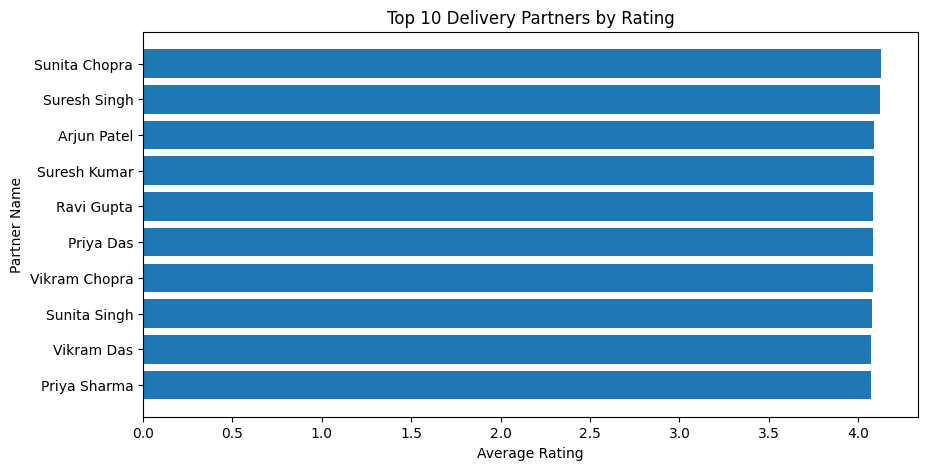

In [10]:
import matplotlib.pyplot as plt

# Average rating for each delivery partner
top10 = (
    data.groupby("Partner_Name")["Order_Rating"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

# Plot
plt.figure(figsize=(10,5))
plt.barh(top10.index, top10.values)

plt.title("Top 10 Delivery Partners by Rating")
plt.xlabel("Average Rating")
plt.ylabel("Partner Name")

plt.gca().invert_yaxis()
plt.show()

In [7]:
data.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Restaurant_ID', 'Region',
       'Delivery_Partner_ID', 'Order_Value', 'Delivery_Fee',
       'Discount_Applied', 'Final_Amount', 'Payment_Mode', 'Order_Status',
       'Delivery_Time_Minutes', 'Order_Rating', 'Festival_Flag',
       'Partner_Name', 'Vehicle_Type', 'Avg_Delivery_Speed_KMPH',
       'Successful_Deliveries', 'Delayed_Deliveries', 'Avg_Customer_Rating',
       'Delivery_Efficiency_Score', 'Avg_Preparation_Time_Minutes',
       'Avg_Rating', 'Order_Capacity_Per_Day', 'Restaurant_Name',
       'Cuisine_Type', 'Gender', 'Age_Group', 'Customer_Type', 'Total_Orders',
       'Average_Spend', 'Preferred_Cuisine'],
      dtype='object')

## FIND

In [7]:
#Cuisine vs Order Value
cuisine_perf = data.groupby('Preferred_Cuisine')["Order_Value"].mean().sort_values(ascending=False)
print(cuisine_perf.head(10))

Preferred_Cuisine
Desserts        547.438453
Chinese         546.145815
Italian         545.893046
South Indian    545.647032
North Indian    544.997553
Fast Food       543.992688
Name: Order_Value, dtype: float64


In [4]:
data.groupby("Cuisine_Type")["Delivery_Efficiency_Score"].mean()

Cuisine_Type
Chinese      0.660620
Fast Food    0.710601
Indian       0.670534
Italian      0.696706
Name: Delivery_Efficiency_Score, dtype: float64

In [5]:
corr = data["Order_Value"].corr(data["Final_Amount"])
print("Correlation:", corr)

Correlation: 0.9710468480434853


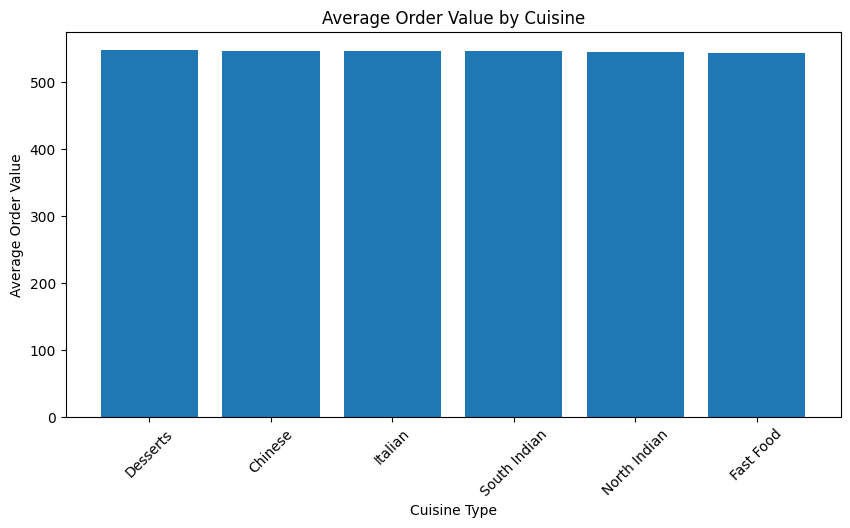

In [8]:
plt.figure(figsize=(10,5))

plt.bar(cuisine_perf.index, cuisine_perf.values)

plt.title("Average Order Value by Cuisine")
plt.xlabel("Cuisine Type")
plt.ylabel("Average Order Value")

plt.xticks(rotation=45)

plt.show()

In [9]:
data.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Restaurant_ID', 'Region',
       'Delivery_Partner_ID', 'Order_Value', 'Delivery_Fee',
       'Discount_Applied', 'Final_Amount', 'Payment_Mode', 'Order_Status',
       'Delivery_Time_Minutes', 'Order_Rating', 'Festival_Flag',
       'Partner_Name', 'Vehicle_Type', 'Avg_Delivery_Speed_KMPH',
       'Successful_Deliveries', 'Delayed_Deliveries', 'Avg_Customer_Rating',
       'Delivery_Efficiency_Score', 'Avg_Preparation_Time_Minutes',
       'Avg_Rating', 'Order_Capacity_Per_Day', 'Restaurant_Name',
       'Cuisine_Type', 'Gender', 'Age_Group', 'Customer_Type', 'Total_Orders',
       'Average_Spend', 'Preferred_Cuisine'],
      dtype='object')

In [11]:
#Delivery Time vs Rating
corr = data["Delivery_Time_Minutes"].corr(data["Order_Rating"])
print("Correlation:", corr)

Correlation: -0.002191314666035123


In [12]:
corr = data["Delivery_Time_Minutes"].corr(data['Avg_Customer_Rating'])
print("Correlation:", corr)

Correlation: -0.0034826698635168326


In [13]:
corr = data["Order_Rating"].corr(data['Avg_Customer_Rating'])
print("Correlation:", corr)

Correlation: -0.004268078690589974


## AVG customer rating

In [14]:
corr = data['Avg_Preparation_Time_Minutes'].corr(data['Avg_Customer_Rating'])
print("Correlation:", corr)

Correlation: -0.31153140516649835


In [15]:
corr = data['Avg_Preparation_Time_Minutes'].corr(data['Order_Rating'])
print("Correlation:", corr)

Correlation: 0.0027032516710651694


In [16]:
corr = data['Avg_Preparation_Time_Minutes'].corr(data['Delivery_Time_Minutes'])
print("Correlation:", corr)

Correlation: 0.0007012203900938351


In [24]:
corr = data['Avg_Preparation_Time_Minutes'].corr(data['Order_Value'])
print("Correlation:", corr)

Correlation: -0.002194703545682764


In [26]:
# Convert festival flag into numeric values
data['Festival_Flag_Num'] = data['Festival_Flag'].map({
    'NON-FESTIVAL': 0,
    'FESTIVAL': 1
})

# Find correlation
corr = data['Festival_Flag_Num'].corr(data['Discount_Applied'])

print("Correlation:", corr)

Correlation: -0.0021339532694257773


In [27]:
# Convert customer types into numbers
data['Customer_Type_Num'] = data['Customer_Type'].map({
    'New': 0,
    'Returning': 1,
    'Loyal': 2
})

# Calculate correlation
corr = data['Customer_Type_Num'].corr(data['Discount_Applied'])

print("Correlation:", corr)

Correlation: -0.0010387928864181027


## Order_Capacity_Per_Day

In [18]:
corr = data['Avg_Preparation_Time_Minutes'].corr(data['Order_Capacity_Per_Day'])
print("Correlation:", corr)

Correlation: -0.3108387630107993


## Discount_Applied

In [23]:
corr = data['Final_Amount'].corr(data['Discount_Applied'])
print("Correlation:", corr)

Correlation: -0.23568891177808804


In [12]:
#Cuisine + Region #Which cuisine performs best in which region
multi = data.groupby(['Preferred_Cuisine', 'Region'])["Order_Value"].mean().round(2)
print(multi)

Preferred_Cuisine  Region       
Chinese            Metropolitian    543.94
                   Semi-Urban       546.54
                   Urban            547.66
Desserts           Metropolitian    547.01
                   Semi-Urban       546.94
                   Urban            548.45
Fast Food          Metropolitian    543.83
                   Semi-Urban       543.69
                   Urban            544.44
Italian            Metropolitian    546.50
                   Semi-Urban       544.18
                   Urban            546.97
North Indian       Metropolitian    544.10
                   Semi-Urban       544.21
                   Urban            546.59
South Indian       Metropolitian    545.46
                   Semi-Urban       545.74
                   Urban            545.72
Name: Order_Value, dtype: float64


In [87]:
data.groupby('Vehicle_Type')['Order_Value'].agg(['mean','median','count'])

,mean,median,count
Vehicle_Type,,,
Bicycle,543.379810,538.0,4210
Bike,545.534470,542.0,46794
Car,546.354548,542.0,18996
Scooter,545.795733,542.0,30000


In [88]:
data.groupby('Vehicle_Type')['Order_Value'].describe()

,count,mean,std,min,25%,50%,75%,max
Vehicle_Type,,,,,,,,
Bicycle,4210.0,543.379810,164.057913,200.0,427.0,538.0,653.0,1200.0
Bike,46794.0,545.534470,167.780435,200.0,429.0,542.0,655.0,1200.0
Car,18996.0,546.354548,166.440238,200.0,429.0,542.0,657.0,1200.0
Scooter,30000.0,545.795733,167.108105,200.0,429.0,542.0,656.0,1200.0


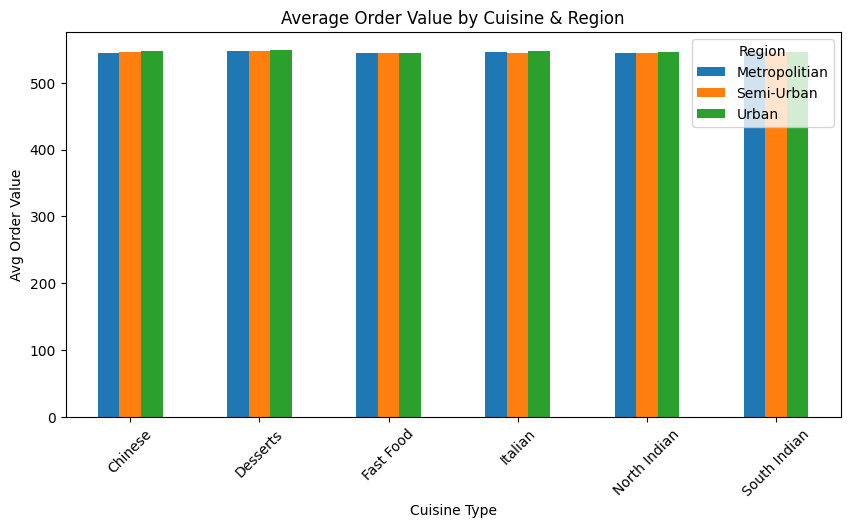

In [13]:
pivot = multi.unstack()

pivot.plot(kind="bar", figsize=(10,5))

plt.title("Average Order Value by Cuisine & Region")
plt.xlabel("Cuisine Type")
plt.ylabel("Avg Order Value")

plt.xticks(rotation=45)

plt.legend(title="Region")

plt.show()

In [14]:
#Which partner struggles in which region
partner_region = data.groupby(['Partner_Name', "Region"])['Delayed_Deliveries'].sum().round(2)
print(partner_region)

Partner_Name   Region       
Anita Chopra   Metropolitian    2037
               Urban             201
Anita Das      Metropolitian     940
               Semi-Urban        491
               Urban             130
                                ... 
Vikram Sharma  Metropolitian    1838
               Urban             112
Vikram Singh   Metropolitian     587
               Semi-Urban        909
               Urban              64
Name: Delayed_Deliveries, Length: 245, dtype: int64


In [15]:
#Which partner struggles in which region
partner_region = data.groupby(['Delivery_Partner_ID', "Region"])['Delayed_Deliveries'].sum()
print(partner_region)

Delivery_Partner_ID  Region       
D0001                Metropolitian    265
D0002                Metropolitian    256
D0003                Urban             63
D0004                Urban              0
D0005                Metropolitian      0
                                     ... 
D1096                Metropolitian     62
D1097                Metropolitian     76
D1098                Urban              0
D1099                Urban              0
D1100                Urban              0
Name: Delayed_Deliveries, Length: 1100, dtype: int64


In [16]:
#Customer Type + Festival

segment = data.groupby(['Customer_Type', "Festival_Flag"])["Order_Value"].mean().round(2)
print(segment)

Customer_Type  Festival_Flag
Loyal          FESTIVAL         582.57
               NON-FESTIVAL     502.40
New            FESTIVAL         580.27
               NON-FESTIVAL     505.20
Returning      FESTIVAL         581.27
               NON-FESTIVAL     506.50
Name: Order_Value, dtype: float64


In [17]:
##How does final amount value vary across customer types?
revenue_by_cust_type = data.groupby('Customer_Type')['Final_Amount'].agg(['sum','mean']).reset_index().round(2)
print(revenue_by_cust_type)

  Customer_Type       sum    mean
0         Loyal   6187406  559.44
1           New  30260711  559.69
2     Returning  19547115  560.52


In [18]:
#How does average order value vary across customer types?
average_order = data.groupby('Customer_Type')['Order_Value'].agg(['sum','mean']).reset_index().round(2)
print(average_order)

  Customer_Type       sum    mean
0         Loyal   6029631  545.17
1           New  29490121  545.44
2     Returning  19048040  546.21


In [19]:
#Do festival periods significantly impact customer spending behavior?
festival_impact = data.groupby('Festival_Flag')['Order_Value'].agg(['sum','mean']).reset_index().round(2)
print(festival_impact)

  Festival_Flag       sum    mean
0      FESTIVAL  31017995  580.87
1  NON-FESTIVAL  23549797  505.35


In [20]:
#Does gender influence spending patterns across orders?
gender_impact = data.groupby('Gender')['Order_Value'].agg(['sum','mean']).reset_index().round(2)
print(gender_impact)

   Gender       sum    mean
0  Female  22929780  545.79
1    Male  28247542  545.46
2   Other   3390470  546.76


In [21]:
data.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Restaurant_ID', 'Region',
       'Delivery_Partner_ID', 'Order_Value', 'Delivery_Fee',
       'Discount_Applied', 'Final_Amount', 'Payment_Mode', 'Order_Status',
       'Delivery_Time_Minutes', 'Order_Rating', 'Festival_Flag',
       'Partner_Name', 'Vehicle_Type', 'Avg_Delivery_Speed_KMPH',
       'Successful_Deliveries', 'Delayed_Deliveries', 'Avg_Customer_Rating',
       'Delivery_Efficiency_Score', 'Avg_Preparation_Time_Minutes',
       'Avg_Rating', 'Order_Capacity_Per_Day', 'Restaurant_Name',
       'Cuisine_Type', 'Gender', 'Age_Group', 'Customer_Type', 'Total_Orders',
       'Average_Spend', 'Preferred_Cuisine'],
      dtype='object')

## Evaluate the impact of temporal and contextual factors on order value

In [22]:
#How does average order value differ between festival and non-festival periods?
festival_revenue = data.groupby('Festival_Flag')['Final_Amount'].agg(['sum','mean']).reset_index()
print(festival_impact)
FESTIVAL =30980575.5
NON_FESTIVAL = 23548381.0
total = FESTIVAL + NON_FESTIVAL
percent_increase =(FESTIVAL/total)*100
print(percent_increase)

  Festival_Flag       sum    mean
0      FESTIVAL  31017995  580.87
1  NON-FESTIVAL  23549797  505.35
56.81490622326506


In [23]:
#Are high-value orders concentrated in specific time periods or conditions?
threshold = data["Order_Value"].quantile(0.75)  # top 25%
high_value = data[data["Order_Value"] >= threshold]
high_value["Festival_Flag"].value_counts()

Festival_Flag
FESTIVAL        17647
NON-FESTIVAL     7362
Name: count, dtype: int64

In [24]:
high_value["Customer_Type"].value_counts()

Customer_Type
New          13469
Returning     8800
Loyal         2740
Name: count, dtype: int64

In [25]:
data.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Restaurant_ID', 'Region',
       'Delivery_Partner_ID', 'Order_Value', 'Delivery_Fee',
       'Discount_Applied', 'Final_Amount', 'Payment_Mode', 'Order_Status',
       'Delivery_Time_Minutes', 'Order_Rating', 'Festival_Flag',
       'Partner_Name', 'Vehicle_Type', 'Avg_Delivery_Speed_KMPH',
       'Successful_Deliveries', 'Delayed_Deliveries', 'Avg_Customer_Rating',
       'Delivery_Efficiency_Score', 'Avg_Preparation_Time_Minutes',
       'Avg_Rating', 'Order_Capacity_Per_Day', 'Restaurant_Name',
       'Cuisine_Type', 'Gender', 'Age_Group', 'Customer_Type', 'Total_Orders',
       'Average_Spend', 'Preferred_Cuisine'],
      dtype='object')

In [26]:
high_value['Region'].value_counts()

Region
Urban            8437
Metropolitian    8300
Semi-Urban       8272
Name: count, dtype: int64

In [27]:
high_value.groupby(['Preferred_Cuisine', "Region"]).size()

Preferred_Cuisine  Region       
Chinese            Metropolitian    1379
                   Semi-Urban       1762
                   Urban            1591
Desserts           Metropolitian    1428
                   Semi-Urban       1281
                   Urban            1261
Fast Food          Metropolitian    1381
                   Semi-Urban       1306
                   Urban            1379
Italian            Metropolitian    1350
                   Semi-Urban       1296
                   Urban            1369
North Indian       Metropolitian    1463
                   Semi-Urban       1089
                   Urban            1377
South Indian       Metropolitian    1299
                   Semi-Urban       1538
                   Urban            1460
dtype: int64

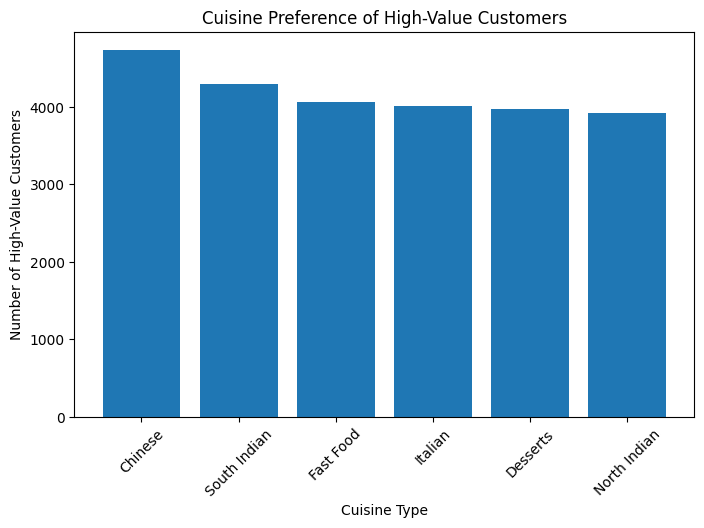

In [28]:
high_value['Preferred_Cuisine'].value_counts()

cuisine_counts = high_value['Preferred_Cuisine'].value_counts()

plt.figure(figsize=(8,5))

plt.bar(cuisine_counts.index, cuisine_counts.values)

plt.title("Cuisine Preference of High-Value Customers")
plt.xlabel("Cuisine Type")
plt.ylabel("Number of High-Value Customers")

plt.xticks(rotation=45)

plt.show()

In [29]:
data.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Restaurant_ID', 'Region',
       'Delivery_Partner_ID', 'Order_Value', 'Delivery_Fee',
       'Discount_Applied', 'Final_Amount', 'Payment_Mode', 'Order_Status',
       'Delivery_Time_Minutes', 'Order_Rating', 'Festival_Flag',
       'Partner_Name', 'Vehicle_Type', 'Avg_Delivery_Speed_KMPH',
       'Successful_Deliveries', 'Delayed_Deliveries', 'Avg_Customer_Rating',
       'Delivery_Efficiency_Score', 'Avg_Preparation_Time_Minutes',
       'Avg_Rating', 'Order_Capacity_Per_Day', 'Restaurant_Name',
       'Cuisine_Type', 'Gender', 'Age_Group', 'Customer_Type', 'Total_Orders',
       'Average_Spend', 'Preferred_Cuisine'],
      dtype='object')

In [52]:
# Compare important factors by Region and Customer Type

analysis = (
    data.groupby(['Region', 'Customer_Type'])[
        [
            'Delivery_Time_Minutes',
            'Order_Rating',
            'Discount_Applied',
            'Avg_Delivery_Speed_KMPH',
            'Delivery_Efficiency_Score',
            'Avg_Preparation_Time_Minutes',
            'Average_Spend',
            'Total_Orders'
        ]
    ]
    .mean()
    .round(2)
)

print(analysis)

                             Delivery_Time_Minutes  Order_Rating  \
Region        Customer_Type                                        
Metropolitian Loyal                          35.51          4.03   
              New                            35.59          4.01   
              Returning                      35.46          4.02   
Semi-Urban    New                            35.51          4.03   
              Returning                      35.47          4.04   
Urban         Loyal                          34.89          4.04   
              New                            35.56          4.03   
              Returning                      35.47          4.02   

                             Discount_Applied  Avg_Delivery_Speed_KMPH  \
Region        Customer_Type                                              
Metropolitian Loyal                     21.36                    22.03   
              New                       21.45                    21.98   
              Returning

In [53]:
# Compare male vs female customer behavior

male_analysis = (
    data.groupby('Gender')[
        [
            'Order_Value',
            'Discount_Applied',
            'Final_Amount',
            'Order_Rating',
            'Delivery_Time_Minutes',
            'Avg_Delivery_Speed_KMPH',
            'Average_Spend',
            'Total_Orders'
        ]
    ]
    .mean()
    .round(2)
)

print(male_analysis)

        Order_Value  Discount_Applied  Final_Amount  Order_Rating  \
Gender                                                              
Female       545.79             21.42        560.06          4.02   
Male         545.46             21.33        559.81          4.02   
Other        546.76             22.03        560.35          4.04   

        Delivery_Time_Minutes  Avg_Delivery_Speed_KMPH  Average_Spend  \
Gender                                                                  
Female                  35.54                    20.26         424.71   
Male                    35.49                    20.78         398.06   
Other                   35.45                    19.38         477.19   

        Total_Orders  
Gender                
Female          4.64  
Male            4.76  
Other           4.27  


In [54]:
# Preferred cuisine by gender

cuisine_gender = (
    data.groupby(['Gender', 'Cuisine_Type'])
    .size()
    .reset_index(name='Customer_Count')
    .sort_values(
        by=['Gender', 'Customer_Count'],
        ascending=[True, False]
    )
)

print(cuisine_gender)

    Gender Cuisine_Type  Customer_Count
3   Female      Italian           12152
0   Female      Chinese           11457
2   Female       Indian            9622
1   Female    Fast Food            8781
7     Male      Italian           15280
4     Male      Chinese           13782
6     Male       Indian           11622
5     Male    Fast Food           11103
11   Other      Italian            1796
8    Other      Chinese            1669
10   Other       Indian            1497
9    Other    Fast Food            1239


In [55]:
# Filter Italian cuisine only
italian_data = data[data['Cuisine_Type'] == 'Italian']

# Restaurant performance by gender and region
italian_restaurants = (
    italian_data.groupby(
        ['Region', 'Gender', 'Restaurant_Name']
    )
    .size()
    .reset_index(name='Customer_Count')
    .sort_values(
        by=['Region', 'Gender', 'Customer_Count'],
        ascending=[True, True, False]
    )
)

print(italian_restaurants)

            Region  Gender  Restaurant_Name  Customer_Count
7    Metropolitian  Female  Restaurant_1172              62
72   Metropolitian  Female   Restaurant_984              61
43   Metropolitian  Female    Restaurant_56              59
68   Metropolitian  Female   Restaurant_948              59
24   Metropolitian  Female   Restaurant_231              55
..             ...     ...              ...             ...
477          Urban   Other   Restaurant_847               3
414          Urban   Other  Restaurant_1036               2
415          Urban   Other  Restaurant_1040               2
418          Urban   Other  Restaurant_1060               2
445          Urban   Other   Restaurant_428               1

[486 rows x 4 columns]


In [56]:
top_restaurants = (
    italian_data.groupby(
        ['Region', 'Gender', 'Restaurant_Name']
    )
    .size()
    .reset_index(name='Count')
)

# Top restaurant
top_restaurants = top_restaurants.loc[
    top_restaurants.groupby(['Region', 'Gender'])['Count'].idxmax()
]

print(top_restaurants)

            Region  Gender  Restaurant_Name  Count
7    Metropolitian  Female  Restaurant_1172     62
77   Metropolitian    Male  Restaurant_1070     78
159  Metropolitian   Other  Restaurant_1191     14
236     Semi-Urban  Female   Restaurant_921    351
239     Semi-Urban    Male   Restaurant_123    356
261     Semi-Urban   Other   Restaurant_813     74
276          Urban  Female  Restaurant_1157     79
376          Urban    Male   Restaurant_494    106
441          Urban   Other   Restaurant_358     12


In [28]:
# Find high-performing restaurants based on average rating
high_perf = (
    data.groupby(['Restaurant_Name', 'Cuisine_Type'])['Avg_Rating']
    .mean()
    .reset_index()
    .sort_values(by='Avg_Rating', ascending=False)
)

# Top 10 high-performing restaurants with cuisine type
print(high_perf.head(10))

    Restaurant_Name Cuisine_Type  Avg_Rating
194  Restaurant_302       Indian         5.0
205  Restaurant_314    Fast Food         5.0
537  Restaurant_977      Chinese         5.0
216  Restaurant_332    Fast Food         5.0
218  Restaurant_334      Chinese         5.0
183   Restaurant_29      Chinese         5.0
176  Restaurant_274      Italian         5.0
186  Restaurant_292    Fast Food         5.0
164  Restaurant_249       Indian         5.0
356   Restaurant_60    Fast Food         5.0


In [57]:
# Analyze why high-rated restaurants perform well

high_rating_analysis = (
    data.groupby('Restaurant_Name')[
        [
            'Avg_Rating',
            'Delivery_Time_Minutes',
            'Avg_Delivery_Speed_KMPH',
            'Delivery_Efficiency_Score',
            'Avg_Preparation_Time_Minutes',
            'Discount_Applied',
            'Order_Rating',
            'Total_Orders',
            'Average_Spend'
        ]
    ]
    .mean()
    .sort_values(by='Avg_Rating', ascending=False)
)

print(high_rating_analysis.head(10))

                 Avg_Rating  Delivery_Time_Minutes  Avg_Delivery_Speed_KMPH  \
Restaurant_Name                                                               
Restaurant_302          5.0              35.470000                21.985945   
Restaurant_314          5.0              36.123077                21.697058   
Restaurant_977          5.0              35.251710                15.851610   
Restaurant_332          5.0              34.620370                21.757589   
Restaurant_334          5.0              35.169492                22.029754   
Restaurant_29           5.0              35.945455                21.937450   
Restaurant_274          5.0              35.490566                22.109299   
Restaurant_292          5.0              35.416667                22.044199   
Restaurant_249          5.0              36.260504                22.300077   
Restaurant_60           5.0              35.868421                22.857921   

                 Delivery_Efficiency_Score  Avg_Pre

In [58]:
# Filter Italian restaurants
italian_data = data[data['Cuisine_Type'] == 'Italian']

# Region + Gender wise Italian restaurant analysis
comparison = (
    italian_data.groupby(
        ['Region', 'Gender', 'Restaurant_Name']
    )[
        [
            'Avg_Rating',
            'Order_Rating',
            'Delivery_Time_Minutes',
            'Avg_Preparation_Time_Minutes',
            'Delivery_Efficiency_Score',
            'Total_Orders',
            'Average_Spend'
        ]
    ]
    .mean()
    .reset_index()
)

# Sort by total orders
comparison = comparison.sort_values(
    by='Total_Orders',
    ascending=False
)

print(comparison.head(20))

            Region  Gender  Restaurant_Name  Avg_Rating  Order_Rating  \
168  Metropolitian   Other   Restaurant_184        4.70      4.666667   
161  Metropolitian   Other   Restaurant_120        4.64      4.222222   
219  Metropolitian   Other   Restaurant_958        4.64      3.555556   
17   Metropolitian  Female   Restaurant_174        4.64      4.200000   
90   Metropolitian    Male   Restaurant_135        4.70      4.285714   
66   Metropolitian  Female   Restaurant_937        4.68      3.962264   
57   Metropolitian  Female   Restaurant_848        4.68      3.820513   
0    Metropolitian  Female  Restaurant_1002        4.61      3.883721   
73   Metropolitian  Female   Restaurant_992        4.59      4.255814   
34   Metropolitian  Female   Restaurant_354        4.70      3.926829   
54   Metropolitian  Female   Restaurant_777        4.58      3.976744   
18   Metropolitian  Female   Restaurant_184        4.70      3.863636   
69   Metropolitian  Female   Restaurant_958        

In [60]:
import pandas as pd

# Region vs Payment Mode count
payment_region = pd.crosstab(data['Region'], data['Payment_Mode'])

print(payment_region)

Payment_Mode   Card  Cash    Upi  Wallet
Region                                  
Metropolitian  8313  3310  16584    5023
Semi-Urban     8237  3369  16661    5082
Urban          8413  3297  16733    4978


In [61]:
import pandas as pd

# Region vs Payment Mode count
payment_region = pd.crosstab(data['Gender'], data['Payment_Mode'])

print(payment_region)

Payment_Mode   Card  Cash    Upi  Wallet
Gender                                  
Female        10581  4124  20996    6311
Male          12872  5244  25824    7847
Other          1510   608   3158     925


In [62]:
data['Gender'].value_counts()

Gender
Male      51787
Female    42012
Other      6201
Name: count, dtype: int64

In [63]:
data.groupby(['Festival_Flag', 'Cuisine_Type'])['Final_Amount'].mean().unstack()

Cuisine_Type,Chinese,Fast Food,Indian,Italian
Festival_Flag,,,,
FESTIVAL,595.370152,596.170676,595.300611,594.339185
NON-FESTIVAL,519.892749,519.462861,519.738734,519.100760


In [64]:
data.groupby('Festival_Flag')['Delivery_Fee'].mean()

Festival_Flag
FESTIVAL        35.681942
NON-FESTIVAL    35.689256
Name: Delivery_Fee, dtype: float64

In [65]:
data.groupby('Festival_Flag')['Order_ID'].count()

Festival_Flag
FESTIVAL        53399
NON-FESTIVAL    46601
Name: Order_ID, dtype: int64

In [68]:
import pandas as pd

# -----------------------------
# 1. Partner Level Aggregation (WITH NAME)
# -----------------------------
partner_summary = data.groupby(['Delivery_Partner_ID', 'Partner_Name']).agg(
    avg_delivery_time=('Delivery_Time_Minutes', 'mean'),
    avg_rating=('Avg_Customer_Rating', 'mean'),
    total_orders=('Order_ID', 'count'),
    successful_deliveries=('Successful_Deliveries', 'sum'),
    delayed_deliveries=('Delayed_Deliveries', 'sum')
)

# -----------------------------
# 2. Success Rate
# -----------------------------
partner_summary['success_rate'] = (
    partner_summary['successful_deliveries'] /
    (partner_summary['successful_deliveries'] + partner_summary['delayed_deliveries'])
)

# -----------------------------
# 3. Performance Score
# -----------------------------
partner_summary['performance_score'] = (
    partner_summary['avg_rating'] * 0.4 +
    partner_summary['success_rate'] * 0.3 -
    partner_summary['avg_delivery_time'] * 0.3
)

# -----------------------------
# 4. TOP 3 DELIVERY PARTNERS
# -----------------------------
top_3 = partner_summary.sort_values('performance_score', ascending=False).head(3)

print("⭐ TOP 3 DELIVERY PARTNERS ⭐")
print(top_3)

# -----------------------------
# 5. BOTTOM 3 DELIVERY PARTNERS
# -----------------------------
bottom_3 = partner_summary.sort_values('performance_score', ascending=True).head(3)

print("\n⚠️ BOTTOM 3 DELIVERY PARTNERS ⚠️")
print(bottom_3)

# -----------------------------
# 6. VEHICLE TYPE ANALYSIS
# -----------------------------
vehicle_analysis = data.groupby('Vehicle_Type').agg(
    avg_delivery_time=('Delivery_Time_Minutes', 'mean'),
    avg_rating=('Avg_Customer_Rating', 'mean'),
    total_success=('Successful_Deliveries', 'sum'),
    total_delay=('Delayed_Deliveries', 'sum'),
    total_orders=('Order_ID', 'count')
)

print("\n🚚 VEHICLE TYPE PERFORMANCE")
print(vehicle_analysis)

⭐ TOP 3 DELIVERY PARTNERS ⭐
                                   avg_delivery_time  avg_rating  \
Delivery_Partner_ID Partner_Name                                   
D0525               Priya Nair             33.766667    4.750000   
D0270               Suresh Chopra          33.758065    4.727273   
D0408               Meena Kumar            33.661017    4.584615   

                                   total_orders  successful_deliveries  \
Delivery_Partner_ID Partner_Name                                         
D0525               Priya Nair               60                    120   
D0270               Suresh Chopra            62                    682   
D0408               Meena Kumar              59                   2242   

                                   delayed_deliveries  success_rate  \
Delivery_Partner_ID Partner_Name                                      
D0525               Priya Nair                      0      1.000000   
D0270               Suresh Chopra              

In [69]:
partner_efficiency = data.groupby(
    ['Delivery_Partner_ID', 'Partner_Name']
)['Delivery_Efficiency_Score'].mean().reset_index()

top_3 = partner_efficiency.sort_values(
    by='Delivery_Efficiency_Score',
    ascending=False
).head(3)

print(top_3)

    Delivery_Partner_ID   Partner_Name  Delivery_Efficiency_Score
628               D0629   Rajesh Patel                      1.000
340               D0341  Suresh Sharma                      0.994
421               D0422      Ravi Nair                      0.994


In [70]:
bottom_3 = partner_efficiency.sort_values(
    by='Delivery_Efficiency_Score',
    ascending=True
).head(3)

print(bottom_3)

    Delivery_Partner_ID   Partner_Name  Delivery_Efficiency_Score
564               D0565    Arjun Singh                      0.260
411               D0412  Suresh Chopra                      0.266
226               D0227     Priya Nair                      0.284


In [71]:
partner_efficiency = data.groupby(
    ['Delivery_Partner_ID', 'Partner_Name']
)['Delivery_Efficiency_Score'].mean().reset_index()

top_3 = partner_efficiency.sort_values('Delivery_Efficiency_Score', ascending=False).head(3)
bottom_3 = partner_efficiency.sort_values('Delivery_Efficiency_Score', ascending=True).head(3)

six_partners = pd.concat([top_3, bottom_3])

six_partners

,Delivery_Partner_ID,Partner_Name,Delivery_Efficiency_Score
628,D0629,Rajesh Patel,1.000
340,D0341,Suresh Sharma,0.994
421,D0422,Ravi Nair,0.994
564,D0565,Arjun Singh,0.260
411,D0412,Suresh Chopra,0.266
226,D0227,Priya Nair,0.284


In [78]:
six_data = data[
    data['Delivery_Partner_ID'].isin(six_partners['Delivery_Partner_ID'])
]
print(six_data)

      Order_ID Order_Date Customer_ID Restaurant_ID      Region  \
15     O553421 2025-03-06      C00411          R496  Semi-Urban   
36     O197336 2024-06-01      C00411          R305  Semi-Urban   
81     O868475 2025-08-27      C04749          R239  Semi-Urban   
90     O448435 2024-02-07      C04749          R151  Semi-Urban   
131    O977139 2023-05-15      C05923          R485  Semi-Urban   
...        ...        ...         ...           ...         ...   
99797  O523605 2023-07-19      C05283          R117  Semi-Urban   
99807  O961143 2023-02-25      C03077          R467  Semi-Urban   
99812  O527506 2023-08-13      C02053          R468  Semi-Urban   
99833  O929361 2024-02-10      C02501          R502  Semi-Urban   
99985  O534075 2024-03-23      C01073          R468  Semi-Urban   

      Delivery_Partner_ID  Order_Value  Delivery_Fee  Discount_Applied  \
15                  D0565          543            30                 0   
36                  D0412          611         

In [73]:
factor_analysis = six_data.groupby(
    ['Delivery_Partner_ID', 'Partner_Name']
).agg(
    avg_delivery_time=('Delivery_Time_Minutes', 'mean'),
    avg_rating=('Avg_Customer_Rating', 'mean'),
    total_success=('Successful_Deliveries', 'sum'),
    total_delay=('Delayed_Deliveries', 'sum'),
    total_orders=('Order_ID', 'count')
).reset_index()

factor_analysis

,Delivery_Partner_ID,Partner_Name,avg_delivery_time,avg_rating,total_success,total_delay,total_orders
0,D0227,Priya Nair,35.422360,4.1,0,483,483
1,D0341,Suresh Sharma,34.500000,4.9,64,0,64
2,D0412,Suresh Chopra,35.846311,3.8,0,488,488
3,D0422,Ravi Nair,35.000000,4.9,72,0,72
4,D0565,Arjun Singh,35.538934,3.7,0,488,488
5,D0629,Rajesh Patel,35.222222,5.0,63,0,63


In [76]:
factor_analysis['success_rate'] = (
    factor_analysis['total_success'] /
    (factor_analysis['total_success'] + factor_analysis['total_delay'])
)
print(factor_analysis['success_rate'])

0    0.0
1    1.0
2    0.0
3    1.0
4    0.0
5    1.0
Name: success_rate, dtype: float64


In [79]:
data[data['Delivery_Partner_ID'].isin(['D0629','D0341','D0422','D0565','D0412','D0227'])][
    ['Delivery_Partner_ID','Partner_Name','Vehicle_Type']
].drop_duplicates()

,Delivery_Partner_ID,Partner_Name,Vehicle_Type
15,D0565,Arjun Singh,Bike
36,D0412,Suresh Chopra,Car
131,D0227,Priya Nair,Bike
6192,D0422,Ravi Nair,Scooter
6566,D0341,Suresh Sharma,Car
7434,D0629,Rajesh Patel,Car


In [80]:
data[data['Delivery_Partner_ID'].isin(['D0629','D0341','D0422','D0565','D0412','D0227'])].groupby(
    ['Delivery_Partner_ID','Vehicle_Type']
).agg(
    avg_delivery_time=('Delivery_Time_Minutes','mean'),
    total_delay=('Delayed_Deliveries','sum'),
    total_success=('Successful_Deliveries','sum')
)

,,avg_delivery_time,total_delay,total_success
Delivery_Partner_ID,Vehicle_Type,,,
D0227,Bike,35.422360,483,0
D0341,Car,34.500000,0,64
D0412,Car,35.846311,488,0
D0422,Scooter,35.000000,0,72
D0565,Bike,35.538934,488,0
D0629,Car,35.222222,0,63


In [92]:
restaurant_rating = data.groupby('Restaurant_Name').agg(
    avg_rating=('Avg_Rating','mean'),
    cuisine=('Cuisine_Type','first'),
    total_orders=('Order_ID','count'),
    avg_delivery_time=('Delivery_Time_Minutes','mean'),
    avg_delivery_fee=('Delivery_Fee','mean')
).reset_index()

top_5 = restaurant_rating.sort_values('avg_rating', ascending=False).head(5)
bottom_5 = restaurant_rating.sort_values('avg_rating', ascending=True).head(5)

In [95]:
top_cuisine = top_5['cuisine'].value_counts()
bottom_cuisine = bottom_5['cuisine'].value_counts()

print("TOP 5 CUISINE DISTRIBUTION:\n", top_cuisine)
print("\nBOTTOM 5 CUISINE DISTRIBUTION:\n", bottom_cuisine)

TOP 5 CUISINE DISTRIBUTION:
 cuisine
Fast Food    2
Chinese      2
Indian       1
Name: count, dtype: int64

BOTTOM 5 CUISINE DISTRIBUTION:
 cuisine
Indian       2
Fast Food    2
Italian      1
Name: count, dtype: int64


In [94]:
comparison = pd.concat([
    top_5.assign(group='Top 5'),
    bottom_5.assign(group='Bottom 5')
])

comparison.groupby('group').agg(
    avg_delivery_time=('avg_delivery_time','mean'),
    avg_orders=('total_orders','mean'),
    avg_delivery_fee=('avg_delivery_fee','mean')
)

,avg_delivery_time,avg_orders,avg_delivery_fee
group,,,
Bottom 5,35.661388,141.8,35.928483
Top 5,35.326930,237.4,35.606615


In [36]:
print(
    data.groupby('Customer_Type')['Discount_Applied']
    .mean()
    .sort_values(ascending=False)
)

Customer_Type
New          21.444227
Returning    21.390474
Loyal        21.312839
Name: Discount_Applied, dtype: float64


In [37]:
print(
    data.groupby('Region')['Discount_Applied']
    .mean()
    .sort_values(ascending=False)
)

Region
Semi-Urban       21.600648
Metropolitian    21.427927
Urban            21.204781
Name: Discount_Applied, dtype: float64


In [38]:
print(
    data.groupby('Region')['Discount_Applied']
    .mean()
    .sort_values(ascending=False)
)

Region
Semi-Urban       21.600648
Metropolitian    21.427927
Urban            21.204781
Name: Discount_Applied, dtype: float64


In [39]:
print(
    data.groupby('Festival_Flag')['Discount_Applied']
    .mean()
)

Festival_Flag
FESTIVAL        21.329894
NON-FESTIVAL    21.503830
Name: Discount_Applied, dtype: float64


In [40]:
print(
    data.groupby('Cuisine_Type')['Discount_Applied']
    .mean()
    .sort_values(ascending=False)
)

Cuisine_Type
Indian       21.721780
Chinese      21.393452
Italian      21.309190
Fast Food    21.239407
Name: Discount_Applied, dtype: float64


In [41]:
print(
    data.groupby('Cuisine_Type')['Discount_Applied']
    .mean()
    .sort_values(ascending=False)
)

Cuisine_Type
Indian       21.721780
Chinese      21.393452
Italian      21.309190
Fast Food    21.239407
Name: Discount_Applied, dtype: float64


In [42]:
print(
    data.groupby('Payment_Mode')['Discount_Applied']
    .mean()
    .sort_values(ascending=False)
)

Payment_Mode
Card      21.700116
Cash      21.533681
Wallet    21.531857
Upi       21.205530
Name: Discount_Applied, dtype: float64


In [43]:
numeric_cols = [
    'Order_Value',
    'Delivery_Fee',
    'Delivery_Time_Minutes',
    'Order_Rating',
    'Average_Spend'
]

for col in numeric_cols:
    corr = data[col].corr(data['Discount_Applied'])
    print(f"{col}: {corr}")

Order_Value: 0.0005069969850232426
Delivery_Fee: 0.0020339570681310024
Delivery_Time_Minutes: -0.005903013317715335
Order_Rating: 0.0055427743409467685
Average_Spend: 0.0006832240489228363


In [46]:
# Create order value ranges
data['Order_Category'] = pd.cut(
    data['Order_Value'],
    bins=[0, 200, 500, 1000, 2000],
    labels=['Low', 'Medium', 'High', 'Very High']
)

# Average discount by order category
print(
    data.groupby('Order_Category')['Discount_Applied']
    .mean()
)

Order_Category
Low          21.343402
Medium       21.410844
High         21.397128
Very High    23.041237
Name: Discount_Applied, dtype: float64


In [45]:
numeric_cols = [
    'Order_Value',
    'Discount_Applied',
    'Delivery_Fee',
    'Delivery_Time_Minutes',
    'Order_Rating',
    'Average_Spend'
]

for col in numeric_cols:
    corr = data['Final_Amount'].corr(data[col])
    print(f"{col}: {corr}")

Order_Value: 0.9710468480434852
Discount_Applied: -0.23568891177808804
Delivery_Fee: 0.03134552552800624
Delivery_Time_Minutes: 0.006282554175236282
Order_Rating: -0.004490561653746872
Average_Spend: 0.0007760116059634297


In [33]:
# Customer demand by Region, Cuisine Type, and Customer Type

region_food_demand = (
    data.groupby(['Region', 'Cuisine_Type', 'Customer_Type'])
    .size()
    .reset_index(name='Customer_Count')
    .sort_values(
        by=['Region', 'Customer_Count'],
        ascending=[True, False]
    )
)

print(region_food_demand)

           Region Cuisine_Type Customer_Type  Customer_Count
11  Metropolitian      Italian     Returning            4279
2   Metropolitian      Chinese     Returning            4264
5   Metropolitian    Fast Food     Returning            3988
8   Metropolitian       Indian     Returning            3484
0   Metropolitian      Chinese         Loyal            2906
9   Metropolitian      Italian         Loyal            2821
3   Metropolitian    Fast Food         Loyal            2667
6   Metropolitian       Indian         Loyal            2532
1   Metropolitian      Chinese           New            1657
10  Metropolitian      Italian           New            1656
4   Metropolitian    Fast Food           New            1544
7   Metropolitian       Indian           New            1432
12     Semi-Urban      Chinese           New           10419
18     Semi-Urban      Italian           New            8905
16     Semi-Urban       Indian           New            8248
14     Semi-Urban    Fas

In [34]:
# Top cuisine demand in each region

top_demand = (
    data.groupby(['Region', 'Cuisine_Type'])
    .size()
    .reset_index(name='Total_Orders')
    .sort_values(
        by=['Region', 'Total_Orders'],
        ascending=[True, False]
    )
)

print(top_demand)

           Region Cuisine_Type  Total_Orders
0   Metropolitian      Chinese          8827
3   Metropolitian      Italian          8756
1   Metropolitian    Fast Food          8199
2   Metropolitian       Indian          7448
4      Semi-Urban      Chinese         10518
7      Semi-Urban      Italian          8989
6      Semi-Urban       Indian          8317
5      Semi-Urban    Fast Food          5525
11          Urban      Italian         11483
8           Urban      Chinese          7563
9           Urban    Fast Food          7399
10          Urban       Indian          6976


In [48]:
print(
    data.groupby(['Region', 'Customer_Type'])
    .size()
    .unstack(fill_value=0)
)

Customer_Type  Loyal    New  Returning
Region                                
Metropolitian  10926   6289      16015
Semi-Urban         0  33057        292
Urban            134  14721      18566


In [49]:
# Total customers
total = len(data)

# Retained customers
retained = len(
    data[data['Customer_Type'].isin(['Returning', 'Loyal'])]
)

# Retention rate
retention_rate = (retained / total) * 100

print("Retention Rate:", retention_rate)

Retention Rate: 45.933


In [50]:
region_retention = data.groupby('Region').apply(
    lambda x: (
        x['Customer_Type'].isin(['Returning', 'Loyal']).sum()
        / len(x)
    ) * 100
)

print(region_retention)

Region
Metropolitian    81.074330
Semi-Urban        0.875588
Urban            55.952844
dtype: float64


In [51]:
print(
    data['Customer_Type']
    .value_counts(normalize=True) * 100
)

Customer_Type
New          54.067
Returning    34.873
Loyal        11.060
Name: proportion, dtype: float64


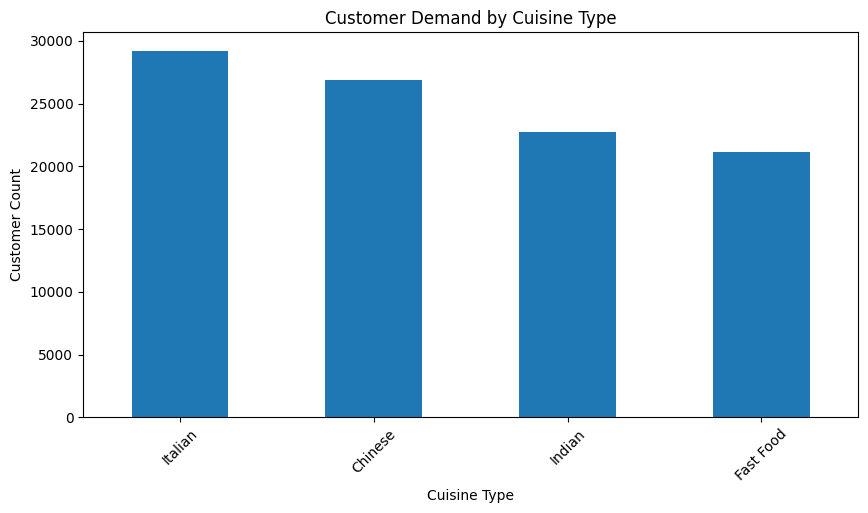

In [35]:
import matplotlib.pyplot as plt

# Customer count by cuisine type
food_count = (
    data.groupby('Cuisine_Type')
    .size()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
food_count.plot(kind='bar')

plt.title("Customer Demand by Cuisine Type")
plt.xlabel("Cuisine Type")
plt.ylabel("Customer Count")

plt.xticks(rotation=45)
plt.show()

## Assess delivery performance and operational efficiency across regions

In [30]:
#Delay Rate
delay_rate = data['Delayed_Deliveries'].mean().round(2)
print("Overall Delay Rate:", delay_rate)


Overall Delay Rate: 1.43


In [31]:
data["Delay_Flag"] = data["Delayed_Deliveries"].apply(lambda x: 1 if x > 0 else 0)

delivery_summary = data.groupby("Region").agg(
    Avg_Time=("Delivery_Time_Minutes", "mean"),
    Std_Dev=("Delivery_Time_Minutes", "std"),
    Delay_Rate=("Delay_Flag", "mean")   # <-- FIX HERE
).round(2)

print(delivery_summary)


               Avg_Time  Std_Dev  Delay_Rate
Region                                      
Metropolitian     35.50     4.89        0.85
Semi-Urban        35.51     4.92        1.00
Urban             35.51     4.93        0.34


In [32]:
from scipy import stats

col = "Delivery_Time_Minutes"

metro = data[data["Region"] == "Metropolitian"][col]
urban = data[data["Region"] == "Urban"][col]
semi  = data[data["Region"] == "Semi-Urban"][col]

t1, p1 = stats.ttest_ind(metro, urban, equal_var=False)
t2, p2 = stats.ttest_ind(metro, semi, equal_var=False)
t3, p3 = stats.ttest_ind(urban, semi, equal_var=False)

alpha = 0.05 / 3  

print("Metro vs Urban:", round(t1, 2), round(p1, 2))
print("Metro vs Semi:", round(t2, 2), round(p2, 2))
print("Urban vs Semi:", round(t3, 2), round(p3, 2))

print("\nAdjusted alpha:", round(alpha, 4)) 

Metro vs Urban: -0.22 0.83
Metro vs Semi: -0.13 0.89
Urban vs Semi: 0.08 0.94

Adjusted alpha: 0.0167


In [33]:
def decision(p):
    return "Significant" if p < alpha else "Not Significant"

print("\nDecisions:")
print("Metro vs Urban:", decision(p1))
print("Metro vs Semi:", decision(p2))
print("Urban vs Semi:", decision(p3))


Decisions:
Metro vs Urban: Not Significant
Metro vs Semi: Not Significant
Urban vs Semi: Not Significant


Interpretation : There is no statistically significant difference in delivery time.

Business Interpretation
1. Delivery system is highly standardized
Same performance across all regions
No regional inefficiency

So:  Strong operational consistency

2. Geography is NOT a driver of delivery time
Being in metro vs semi-urban doesn’t matter

So: Region is a weak variable for predicting delivery time

3. Good scalability signal
System works equally well everywhere
Expansion risk is low

4. Focus should shift elsewhere

Since region has no impact:

Real drivers are likely:
Distance
Traffic
Delivery partner performance
Order volume

## Analyze the impact of delivery delays on customer satisfaction

In [34]:
#Do delayed deliveries lead to lower customer ratings?
data["Delay_Flag"] = data["Delayed_Deliveries"].apply(lambda x: 1 if x > 0 else 0)

deliveries_impact = data.groupby("Delay_Flag")['Order_Rating'].agg(['sum','mean']).reset_index().round(2)
print(deliveries_impact)

   Delay_Flag     sum  mean
0           0  107766  4.02
1           1  294557  4.03


In [35]:
def delay_bucket(x):
    if x == 0:
        return "No Delay"
    elif x <= 2:
        return "Low Delay"
    elif x <= 5:
        return "Medium Delay"
    else:
        return "High Delay"

data["Delay_Category"] = data["Delayed_Deliveries"].apply(delay_bucket)

impact = data.groupby("Delay_Category")["Order_Rating"].mean().round(2)
print(impact)

Delay_Category
High Delay      4.01
Low Delay       4.03
Medium Delay    4.02
No Delay        4.02
Name: Order_Rating, dtype: float64


In [36]:
data["Delay_Flag"] = (data["Delayed_Deliveries"] > 0).astype(int)
avg_rating = data.groupby("Delay_Flag")["Order_Rating"].mean().round(3)
print(avg_rating)


Delay_Flag
0    4.016
1    4.026
Name: Order_Rating, dtype: float64


In [37]:
difference = avg_rating[1] - avg_rating[0]
print("Difference (Delayed - On-time):", round(difference, 3))

result = data.groupby("Delay_Flag")["Order_Rating"].agg(['mean', 'count']).round(3)
print(result)

Difference (Delayed - On-time): 0.01
             mean  count
Delay_Flag              
0           4.016  26832
1           4.026  73168


In [38]:
from scipy import stats

fast = data[data["Delivery_Time_Minutes"] <= 35]["Order_Rating"]
slow = data[data["Delivery_Time_Minutes"] > 35]["Order_Rating"]

t_stat, p_val = stats.ttest_ind(fast, slow, equal_var=False)

print(t_stat, p_val)

0.7905510431831778 0.42920789991889313


1. Ratings are almost identical across all delay levels
Range: 4.01 → 4.03
Difference: 0.02

2. No meaningful impact of delays on ratings

Customer satisfaction (ratings) does not significantly change with delay intensity

3. An independent t-test shows no statistically significant difference in customer ratings between fast and slow deliveries (p = 0.429).

Business Insight
Customers are tolerant to delays
Small or even moderate delays do not strongly affect ratings
Customers may care more about:
food quality
taste
packaging
overall experience

Delay is not the main driver of satisfaction

Delivery timing alone is a weak factor in determining customer ratings


## Evaluate delivery partner performance to identify operational strengths and weaknesses

In [39]:
#Which delivery partners have the lowest delay rates and fastest delivery times?
partner_stats = data.groupby("Partner_Name").agg(
    avg_delivery_time=("Delivery_Time_Minutes", "mean"),
    total_orders=("Order_ID", "count"),
    delayed_orders=("Delay_Flag", "sum"),
    avg_rating=("Avg_Customer_Rating", "mean")
).reset_index()

In [40]:
data.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Restaurant_ID', 'Region',
       'Delivery_Partner_ID', 'Order_Value', 'Delivery_Fee',
       'Discount_Applied', 'Final_Amount', 'Payment_Mode', 'Order_Status',
       'Delivery_Time_Minutes', 'Order_Rating', 'Festival_Flag',
       'Partner_Name', 'Vehicle_Type', 'Avg_Delivery_Speed_KMPH',
       'Successful_Deliveries', 'Delayed_Deliveries', 'Avg_Customer_Rating',
       'Delivery_Efficiency_Score', 'Avg_Preparation_Time_Minutes',
       'Avg_Rating', 'Order_Capacity_Per_Day', 'Restaurant_Name',
       'Cuisine_Type', 'Gender', 'Age_Group', 'Customer_Type', 'Total_Orders',
       'Average_Spend', 'Preferred_Cuisine', 'Delay_Flag', 'Delay_Category'],
      dtype='object')

In [41]:
partner_stats["delay_rate"] = (
    partner_stats["delayed_orders"] / partner_stats["total_orders"]
)

In [42]:
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

partner_stats = data.groupby("Partner_Name").agg(
    avg_delivery_time=("Delivery_Time_Minutes", "mean"),
    delayed_orders=("Delay_Flag", "mean"),
    avg_rating=("Avg_Customer_Rating", "mean")
).reset_index()

top10 = partner_stats.sort_values("avg_rating", ascending=False).head(10)

scaler = MinMaxScaler()

top10[["rating_norm", "time_norm", "delay_norm"]] = scaler.fit_transform(
    top10[["avg_rating", "avg_delivery_time", "delayed_orders"]]
)

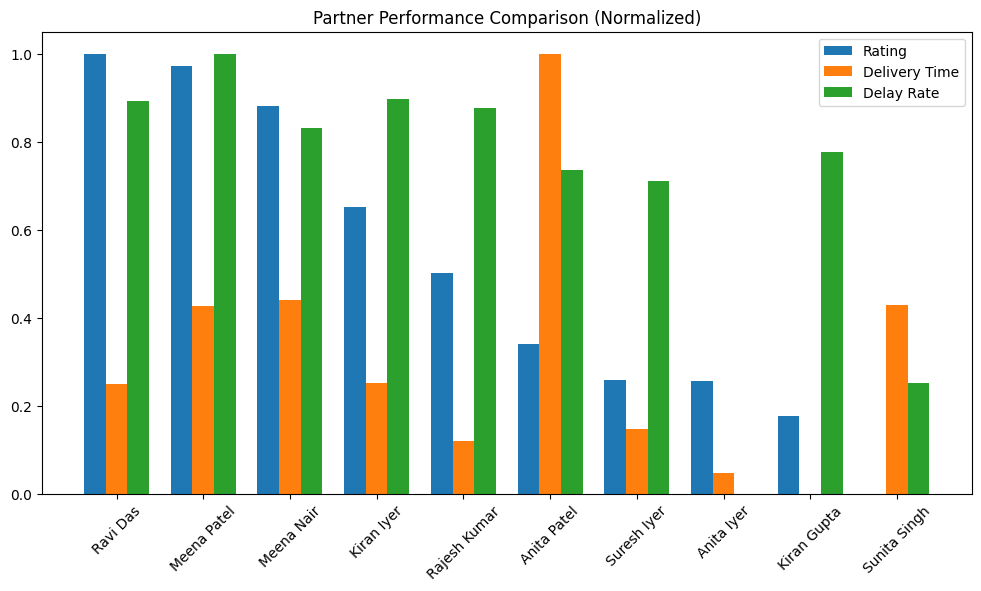

In [43]:
import numpy as np

x = np.arange(len(top10))
width = 0.25

plt.figure(figsize=(12,6))

plt.bar(x - width, top10["rating_norm"], width, label="Rating")
plt.bar(x, top10["time_norm"], width, label="Delivery Time")
plt.bar(x + width, top10["delay_norm"], width, label="Delay Rate")

plt.xticks(x, top10["Partner_Name"], rotation=45)

plt.title("Partner Performance Comparison (Normalized)")
plt.legend()

plt.show()

In [44]:
data.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Restaurant_ID', 'Region',
       'Delivery_Partner_ID', 'Order_Value', 'Delivery_Fee',
       'Discount_Applied', 'Final_Amount', 'Payment_Mode', 'Order_Status',
       'Delivery_Time_Minutes', 'Order_Rating', 'Festival_Flag',
       'Partner_Name', 'Vehicle_Type', 'Avg_Delivery_Speed_KMPH',
       'Successful_Deliveries', 'Delayed_Deliveries', 'Avg_Customer_Rating',
       'Delivery_Efficiency_Score', 'Avg_Preparation_Time_Minutes',
       'Avg_Rating', 'Order_Capacity_Per_Day', 'Restaurant_Name',
       'Cuisine_Type', 'Gender', 'Age_Group', 'Customer_Type', 'Total_Orders',
       'Average_Spend', 'Preferred_Cuisine', 'Delay_Flag', 'Delay_Category'],
      dtype='object')

In [45]:
#Are certain partners underperforming in specific regions?

partner_region_stats = data.groupby(["Partner_Name", "Region"]).agg(
    total_orders=("Order_ID", "count"),
    avg_delivery_time=("Delivery_Time_Minutes", "mean"),
    delay_rate=("Delay_Flag", "mean"),
    avg_rating=("Avg_Customer_Rating", "mean")
).reset_index()

partner_region_stats = partner_region_stats[
    partner_region_stats["total_orders"] >= 100
]

In [46]:
worst_delay = partner_region_stats.sort_values(
    ["Region", "delay_rate"],
    ascending=[True, False]
).groupby("Region").head(3)

print(worst_delay)

     Partner_Name         Region  total_orders  avg_delivery_time  delay_rate  \
0    Anita Chopra  Metropolitian           364          35.535714    1.000000   
5     Anita Gupta  Metropolitian           450          35.388889    1.000000   
9     Anita Kumar  Metropolitian           419          35.742243    1.000000   
3       Anita Das     Semi-Urban           491          35.771894    1.000000   
6     Anita Gupta     Semi-Urban           451          35.487805    1.000000   
12     Anita Nair     Semi-Urban           496          35.463710    1.000000   
171   Ravi Sharma          Urban           267          35.524345    1.000000   
114    Priya Nair          Urban           246          34.593496    0.756098   
111   Priya Kumar          Urban           242          35.136364    0.752066   

     avg_rating  
0      4.595468  
5      4.651806  
9      4.606390  
3      4.100000  
6      4.100000  
12     4.650000  
171    4.667748  
114    4.653027  
111    4.671940  


## Identify high-performing cuisines and restaurant characteristics

In [47]:
#Which cuisine types generate the highest average order value?
cuisine_impact = data.groupby('Cuisine_Type')['Order_Value'].mean().round(2)
print(cuisine_impact)

Cuisine_Type
Chinese      545.95
Fast Food    546.23
Indian       546.05
Italian      544.74
Name: Order_Value, dtype: float64


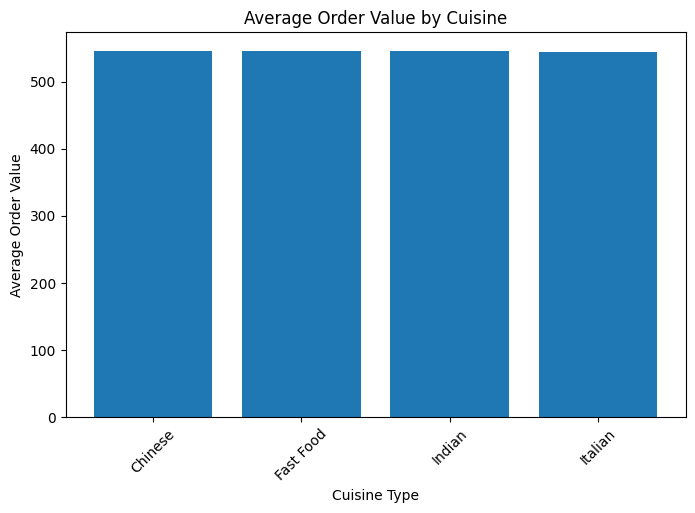

In [48]:
plt.figure(figsize=(8,5))

plt.bar(cuisine_impact.index, cuisine_impact.values)

plt.title("Average Order Value by Cuisine")
plt.xlabel("Cuisine Type")
plt.ylabel("Average Order Value")

plt.xticks(rotation=45)

plt.show()

Preferred_Cuisine
Chinese         546.15
Desserts        547.44
Fast Food       543.99
Italian         545.89
North Indian    545.00
South Indian    545.65
Name: Order_Value, dtype: float64


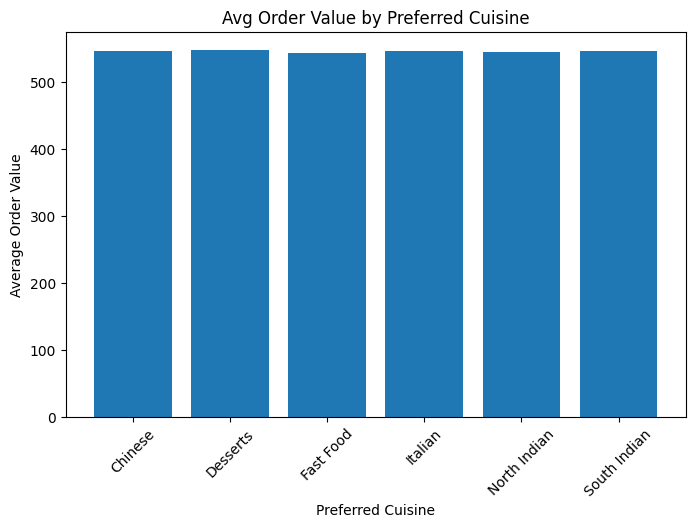

In [49]:
cuisine_impact = data.groupby('Preferred_Cuisine')['Order_Value'].mean().round(2)
print(cuisine_impact)
plt.figure(figsize=(8,5))

plt.bar(cuisine_impact.index, cuisine_impact.values)

plt.title("Avg Order Value by Preferred Cuisine")
plt.xlabel("Preferred Cuisine")
plt.ylabel("Average Order Value")

plt.xticks(rotation=45)

plt.show()

In [50]:
#Do higher-rated restaurants receive higher order values?

restaurant_stats = data.groupby("Restaurant_Name").agg(
    avg_rating=("Avg_Rating", "mean"),
    avg_order_value=("Order_Value", "mean"),
    total_orders=("Order_ID", "count")
).reset_index()

correlation = restaurant_stats[["avg_rating", "avg_order_value"]].corr()

print(correlation)

                 avg_rating  avg_order_value
avg_rating         1.000000         0.006922
avg_order_value    0.006922         1.000000


In [51]:
print(restaurant_stats)

     Restaurant_Name  avg_rating  avg_order_value  total_orders
0      Restaurant_10        4.64       572.188406           138
1     Restaurant_100        4.64       563.682171           129
2    Restaurant_1000        4.25       550.749621           659
3    Restaurant_1001        4.64       540.690141           142
4    Restaurant_1002        4.61       535.433628           113
..               ...         ...              ...           ...
545   Restaurant_989        4.62       543.319672           122
546   Restaurant_992        4.59       550.696000           125
547   Restaurant_996        4.64       552.937931           145
548   Restaurant_997        4.62       524.706422           109
549   Restaurant_999        4.60       571.105263            95

[550 rows x 4 columns]


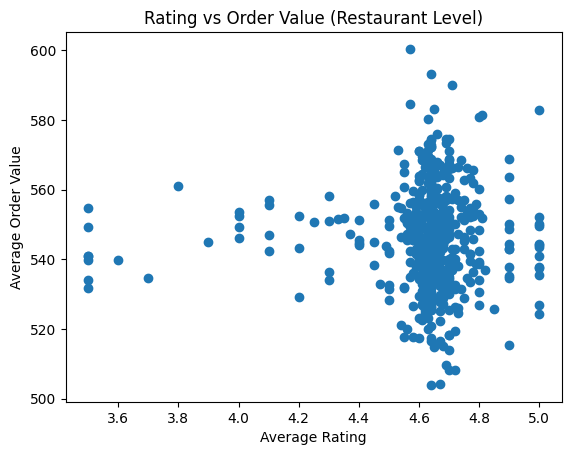

In [52]:
import matplotlib.pyplot as plt

plt.scatter(
    restaurant_stats["avg_rating"],
    restaurant_stats["avg_order_value"]
)

plt.xlabel("Average Rating")
plt.ylabel("Average Order Value")
plt.title("Rating vs Order Value (Restaurant Level)")
plt.show()

In [53]:
data.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Restaurant_ID', 'Region',
       'Delivery_Partner_ID', 'Order_Value', 'Delivery_Fee',
       'Discount_Applied', 'Final_Amount', 'Payment_Mode', 'Order_Status',
       'Delivery_Time_Minutes', 'Order_Rating', 'Festival_Flag',
       'Partner_Name', 'Vehicle_Type', 'Avg_Delivery_Speed_KMPH',
       'Successful_Deliveries', 'Delayed_Deliveries', 'Avg_Customer_Rating',
       'Delivery_Efficiency_Score', 'Avg_Preparation_Time_Minutes',
       'Avg_Rating', 'Order_Capacity_Per_Day', 'Restaurant_Name',
       'Cuisine_Type', 'Gender', 'Age_Group', 'Customer_Type', 'Total_Orders',
       'Average_Spend', 'Preferred_Cuisine', 'Delay_Flag', 'Delay_Category'],
      dtype='object')

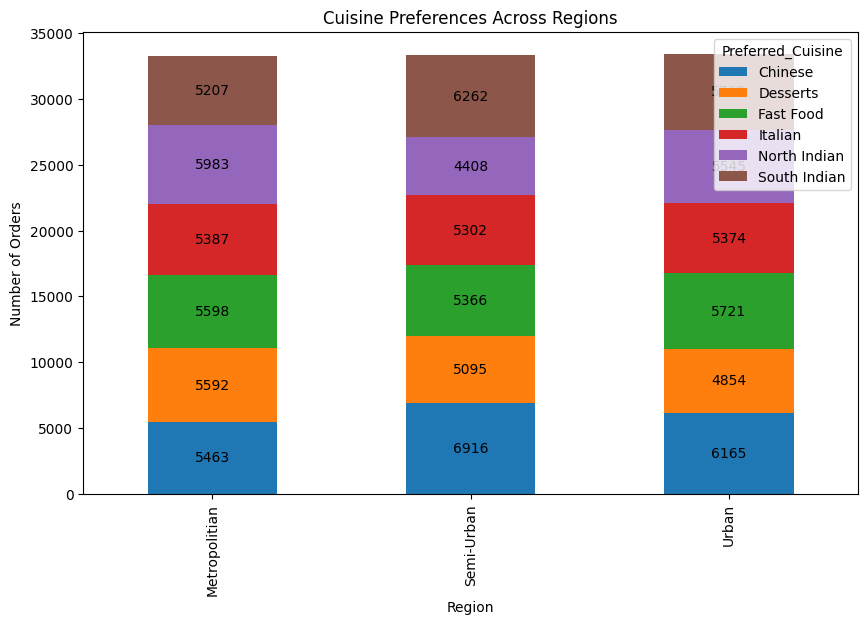

In [54]:
#How do cuisine preferences vary across regions?

cuisine_counts = data.groupby(["Region",'Preferred_Cuisine']).agg(
    total_orders=("Order_ID", "count")
).reset_index()

pivot_counts = cuisine_counts.pivot(
    index="Region",
    columns="Preferred_Cuisine",
    values="total_orders"
).fillna(0)

ax = pivot_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

ax.set_ylabel("Number of Orders")
ax.set_title("Cuisine Preferences Across Regions")

for container in ax.containers:
    ax.bar_label(container, label_type='center')

## Perform multivariate analysis to uncover interaction effects between variables


In [55]:
# How does customer type influence spending during festival vs non-festival periods?
festival_analysis = data.groupby(["Customer_Type", "Festival_Flag"]).agg(
    avg_order_value=("Order_Value", "mean"),
    avg_spend=("Average_Spend", "mean"),
    total_orders=("Order_ID", "count")
).reset_index()

print(festival_analysis)

  Customer_Type Festival_Flag  avg_order_value   avg_spend  total_orders
0         Loyal      FESTIVAL       582.571259  343.043891          5901
1         Loyal  NON-FESTIVAL       502.399302  341.689862          5159
2           New      FESTIVAL       580.274710  495.757351         28976
3           New  NON-FESTIVAL       505.204296  496.920888         25091
4     Returning      FESTIVAL       581.265630  309.421337         18522
5     Returning  NON-FESTIVAL       506.503455  309.764540         16351


Festival_Flag    FESTIVAL  NON-FESTIVAL
Customer_Type                          
Loyal          582.571259    502.399302
New            580.274710    505.204296
Returning      581.265630    506.503455


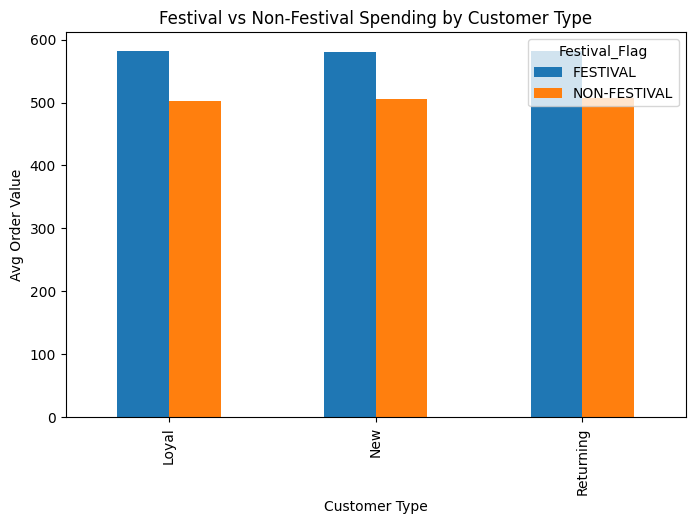

In [56]:
festival_pivot = festival_analysis.pivot(
    index="Customer_Type",
    columns="Festival_Flag",
    values="avg_order_value"
)

print(festival_pivot)

festival_pivot.plot(kind="bar", figsize=(8,5))

plt.title("Festival vs Non-Festival Spending by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Avg Order Value")

plt.show()

In [57]:
#Which cuisine performs best in each region?
cuisine_region = data.groupby(["Region", "Cuisine_Type"]).agg(
    total_orders=("Order_ID", "count"),
    avg_order_value=("Order_Value", "mean"),
    avg_rating=("Avg_Rating", "mean")
).reset_index()

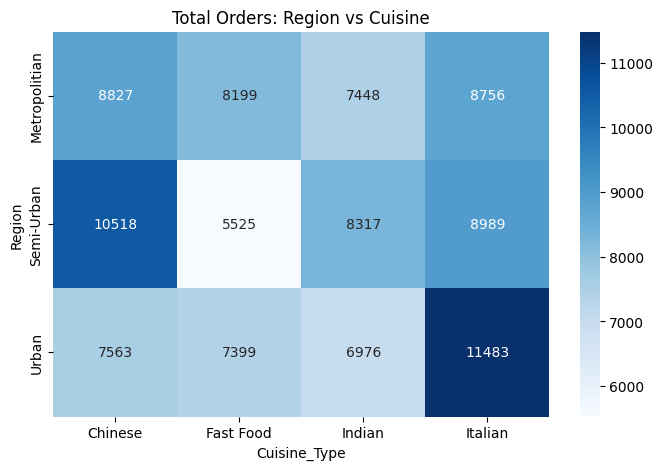

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pivot for heatmap (Total Orders)
heatmap_data = cuisine_region.pivot(
    index="Region",
    columns="Cuisine_Type",
    values="total_orders"
)

plt.figure(figsize=(8,5))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="Blues")

plt.title("Total Orders: Region vs Cuisine")
plt.show()

In [59]:
#best cuisine per region (by orders)

best_by_demand = cuisine_region.loc[
    cuisine_region.groupby("Region")["total_orders"].idxmax()
]

print(best_by_demand[[
    "Region",
    "Cuisine_Type",
    "total_orders",
    "avg_order_value",
    "avg_rating"
]])

           Region Cuisine_Type  total_orders  avg_order_value  avg_rating
0   Metropolitian      Chinese          8827       543.506741    4.615964
4      Semi-Urban      Chinese         10518       546.208785    4.469892
11          Urban      Italian         11483       545.359749    4.659898


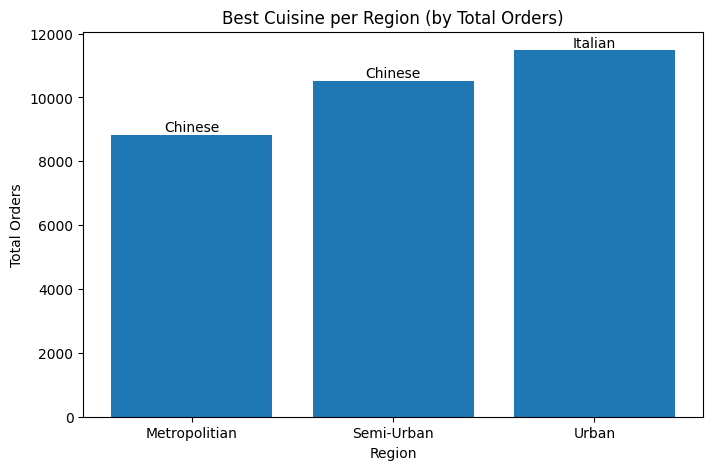

In [60]:
plt.figure(figsize=(8,5))

plt.bar(
    best_by_demand["Region"],
    best_by_demand["total_orders"]
)

plt.title("Best Cuisine per Region (by Total Orders)")
plt.xlabel("Region")
plt.ylabel("Total Orders")

# show cuisine name on top of bars
for i, row in best_by_demand.iterrows():
    plt.text(
        row["Region"],
        row["total_orders"],
        row["Cuisine_Type"],
        ha="center",
        va="bottom"
    )

plt.show()

In [61]:
#Best cuisine by revenue (order value)
best_by_revenue = cuisine_region.loc[
    cuisine_region.groupby("Region")["avg_order_value"].idxmax()
]

print(best_by_revenue[[
    "Region",
    "Cuisine_Type",
    "avg_order_value",
    "total_orders"
]])

          Region Cuisine_Type  avg_order_value  total_orders
1  Metropolitian    Fast Food       547.011953          8199
6     Semi-Urban       Indian       546.331369          8317
8          Urban      Chinese       548.444929          7563


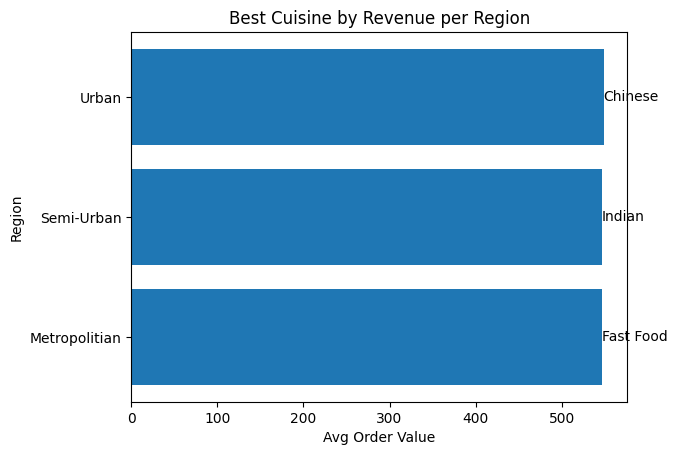

In [62]:
plt.barh(
    best_by_revenue["Region"],
    best_by_revenue["avg_order_value"]
)

plt.title("Best Cuisine by Revenue per Region")
plt.xlabel("Avg Order Value")
plt.ylabel("Region")

# add cuisine labels
for i, row in best_by_revenue.iterrows():
    plt.text(
        row["avg_order_value"],
        row["Region"],
        row["Cuisine_Type"],
        va="center"
    )

plt.show()

In [63]:
#Best cuisine by customer satisfaction

best_by_rating = cuisine_region.loc[
    cuisine_region.groupby("Region")["avg_rating"].idxmax()
]

print(best_by_rating[[
    "Region",
    "Cuisine_Type",
    "avg_rating",
    "total_orders"
]])

          Region Cuisine_Type  avg_rating  total_orders
3  Metropolitian      Italian    4.638331          8756
5     Semi-Urban    Fast Food    4.530907          5525
8          Urban      Chinese    4.679732          7563


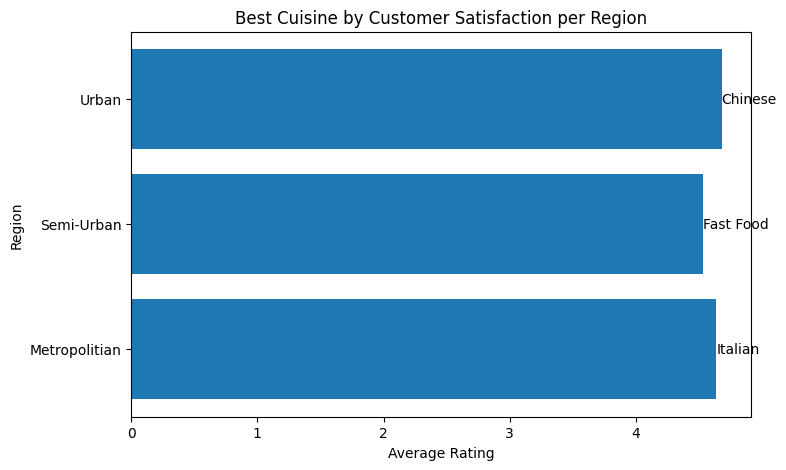

In [64]:
plt.figure(figsize=(8,5))

plt.barh(
    best_by_rating["Region"],
    best_by_rating["avg_rating"]
)

plt.title("Best Cuisine by Customer Satisfaction per Region")
plt.xlabel("Average Rating")
plt.ylabel("Region")

# add cuisine labels
for i, row in best_by_rating.iterrows():
    plt.text(
        row["avg_rating"],
        row["Region"],
        row["Cuisine_Type"],
        va="center"
    )

plt.show()

#How does delivery partner performance vary across different regions?

In [65]:
partner_region = data.groupby(["Partner_Name", "Region"]).agg(
    total_orders=("Order_ID", "count"),
    avg_delivery_time=("Delivery_Time_Minutes", "mean"),
    delay_rate=("Delay_Flag", "mean"),
    avg_rating=("Avg_Customer_Rating", "mean")
).reset_index()

partner_region = partner_region[partner_region["total_orders"] >= 30]

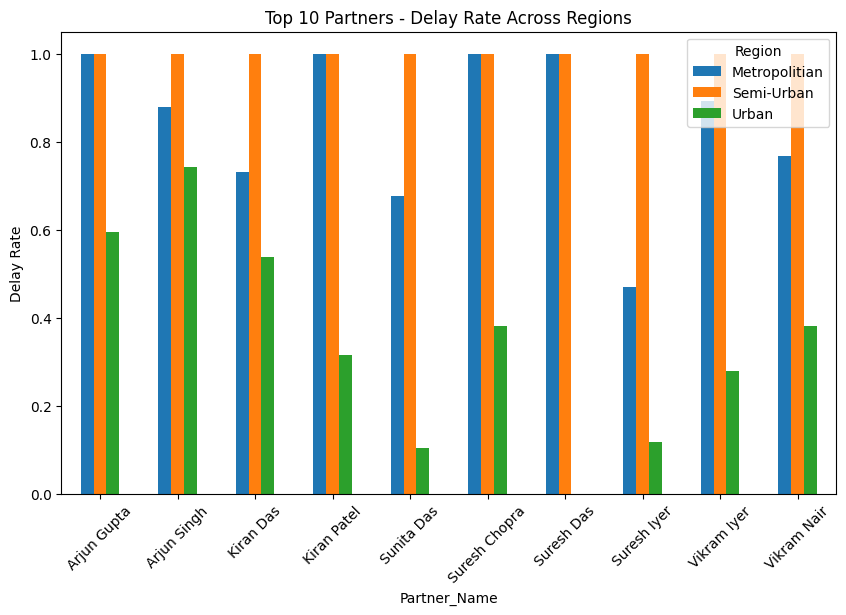

In [66]:
top_partners = partner_region.groupby("Partner_Name")["total_orders"].sum().nlargest(10).index
top_data = partner_region[partner_region["Partner_Name"].isin(top_partners)]

pivot = top_data.pivot(
    index="Partner_Name",
    columns="Region",
    values="delay_rate"
)

pivot.plot(kind="bar", figsize=(10,6))

plt.title("Top 10 Partners - Delay Rate Across Regions")
plt.ylabel("Delay Rate")
plt.xticks(rotation=45)

plt.legend(title="Region")
plt.show()

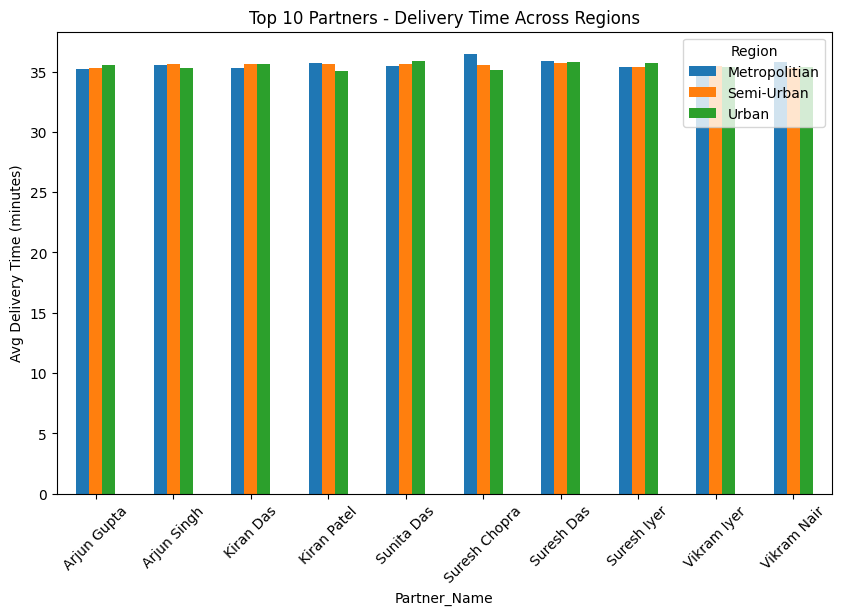

In [67]:
pivot_time = top_data.pivot(
    index="Partner_Name",
    columns="Region",
    values="avg_delivery_time"
)

pivot_time.plot(kind="bar", figsize=(10,6))

plt.title("Top 10 Partners - Delivery Time Across Regions")
plt.ylabel("Avg Delivery Time (minutes)")
plt.xticks(rotation=45)

plt.legend(title="Region")
plt.show()

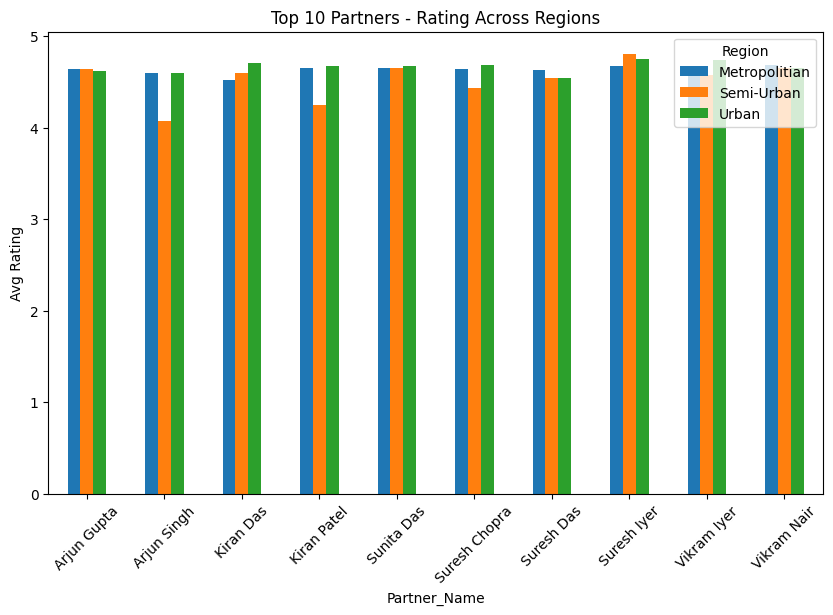

In [68]:
pivot_rating = top_data.pivot(
    index="Partner_Name",
    columns="Region",
    values="avg_rating"
)

pivot_rating.plot(kind="bar", figsize=(10,6))

plt.title("Top 10 Partners - Rating Across Regions")
plt.ylabel("Avg Rating")
plt.xticks(rotation=45)

plt.legend(title="Region")
plt.show()

In [69]:
#Best partners per region (fastest delivery)
fastest = partner_region.loc[
    partner_region.groupby("Region")["avg_delivery_time"].idxmin()
]

print(fastest)

      Partner_Name         Region  total_orders  avg_delivery_time  \
217  Suresh Sharma  Metropolitian           119          34.705882   
24    Arjun Chopra     Semi-Urban           486          35.117284   
114     Priya Nair          Urban           246          34.593496   

     delay_rate  avg_rating  
217    1.000000    4.621609  
24     1.000000    4.600000  
114    0.756098    4.653027  


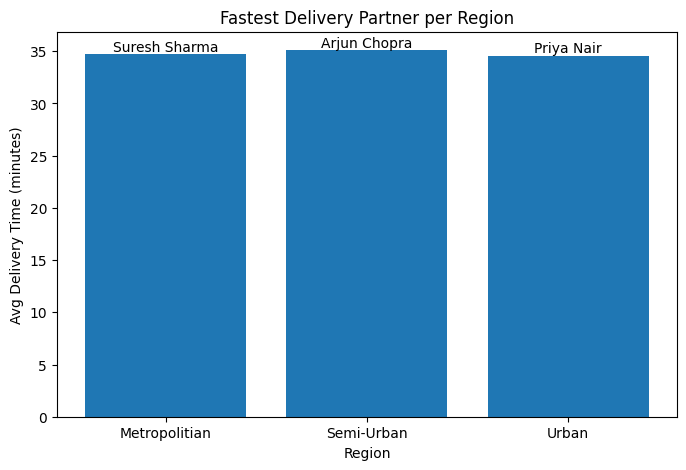

In [70]:
import matplotlib.pyplot as plt

fastest = partner_region.loc[
    partner_region.groupby("Region")["avg_delivery_time"].idxmin()
]

plt.figure(figsize=(8,5))

plt.bar(
    fastest["Region"],
    fastest["avg_delivery_time"]
)

plt.title("Fastest Delivery Partner per Region")
plt.xlabel("Region")
plt.ylabel("Avg Delivery Time (minutes)")

# show partner name on bars
for i, row in fastest.iterrows():
    plt.text(
        row["Region"],
        row["avg_delivery_time"],
        row["Partner_Name"],
        ha="center",
        va="bottom"
    )

plt.show()

In [71]:
#Most reliable partners per region (lowest delay rate)

most_reliable = partner_region.loc[
    partner_region.groupby("Region")["delay_rate"].idxmin()
]

print(most_reliable)

   Partner_Name         Region  total_orders  avg_delivery_time  delay_rate  \
38   Arjun Nair  Metropolitian           121          35.090909         0.0   
3     Anita Das     Semi-Urban           491          35.771894         1.0   
18  Anita Reddy          Urban            57          34.842105         0.0   

    avg_rating  
38    4.727603  
3     4.100000  
18    4.650000  


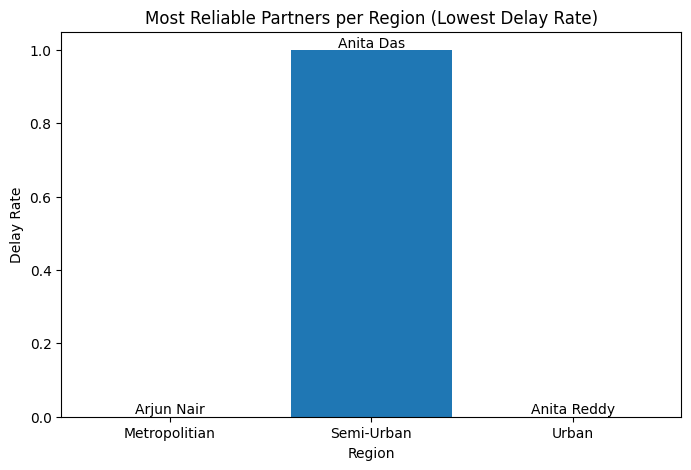

In [72]:
import matplotlib.pyplot as plt

most_reliable = partner_region.loc[
    partner_region.groupby("Region")["delay_rate"].idxmin()
]

plt.figure(figsize=(8,5))

plt.bar(
    most_reliable["Region"],
    most_reliable["delay_rate"]
)

plt.title("Most Reliable Partners per Region (Lowest Delay Rate)")
plt.xlabel("Region")
plt.ylabel("Delay Rate")

# add partner name on bars
for i, row in most_reliable.iterrows():
    plt.text(
        row["Region"],
        row["delay_rate"],
        row["Partner_Name"],
        ha="center",
        va="bottom"
    )

plt.show()

In [73]:
#Highest rated partners per region
top_rated = partner_region.loc[
    partner_region.groupby("Region")["avg_rating"].idxmax()
]

print(top_rated)

     Partner_Name         Region  total_orders  avg_delivery_time  delay_rate  \
38     Arjun Nair  Metropolitian           121          35.090909         0.0   
56    Kiran Gupta     Semi-Urban           504          35.505952         1.0   
227  Vikram Gupta          Urban           107          34.691589         0.0   

     avg_rating  
38     4.727603  
56     5.000000  
227    4.850000  


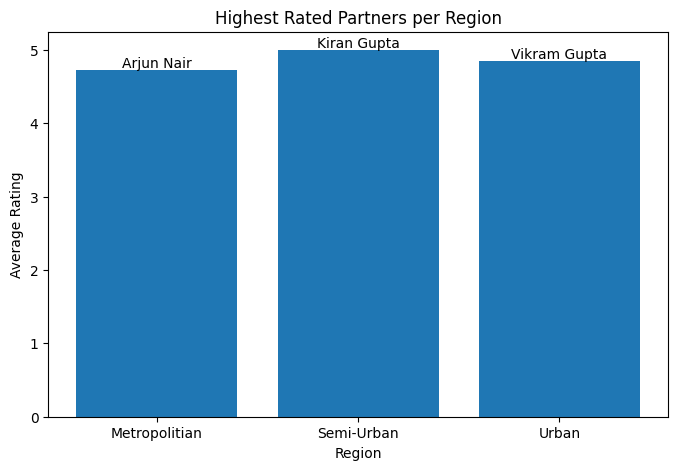

In [74]:
import matplotlib.pyplot as plt

top_rated = partner_region.loc[
    partner_region.groupby("Region")["avg_rating"].idxmax()
]

plt.figure(figsize=(8,5))

plt.bar(
    top_rated["Region"],
    top_rated["avg_rating"]
)

plt.title("Highest Rated Partners per Region")
plt.xlabel("Region")
plt.ylabel("Average Rating")

# add partner names on bars
for i, row in top_rated.iterrows():
    plt.text(
        row["Region"],
        row["avg_rating"],
        row["Partner_Name"],
        ha="center",
        va="bottom"
    )

plt.show()

In [75]:
#What combination of factors (region, cuisine, customer type) drives higher revenue?
combo = data.groupby(
    ["Region", "Cuisine_Type", "Customer_Type"]
).agg(
    total_orders=("Order_ID", "count"),
    avg_order_value=("Order_Value", "mean"),
    total_revenue=("Order_Value", "sum")
).reset_index()

combo = combo[combo["total_orders"] >= 30]

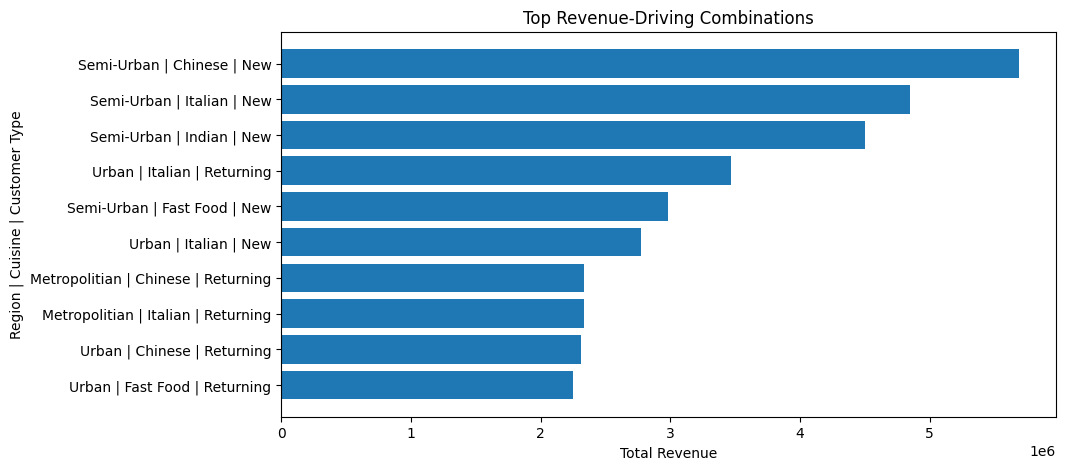

In [76]:
import matplotlib.pyplot as plt

top_combo = combo.sort_values("total_revenue", ascending=False).head(10)

labels = (
    top_combo["Region"] + " | " +
    top_combo["Cuisine_Type"] + " | " +
    top_combo["Customer_Type"]
)

plt.figure(figsize=(10,5))

plt.barh(labels, top_combo["total_revenue"])

plt.title("Top Revenue-Driving Combinations")
plt.xlabel("Total Revenue")
plt.ylabel("Region | Cuisine | Customer Type")

plt.gca().invert_yaxis()
plt.show()

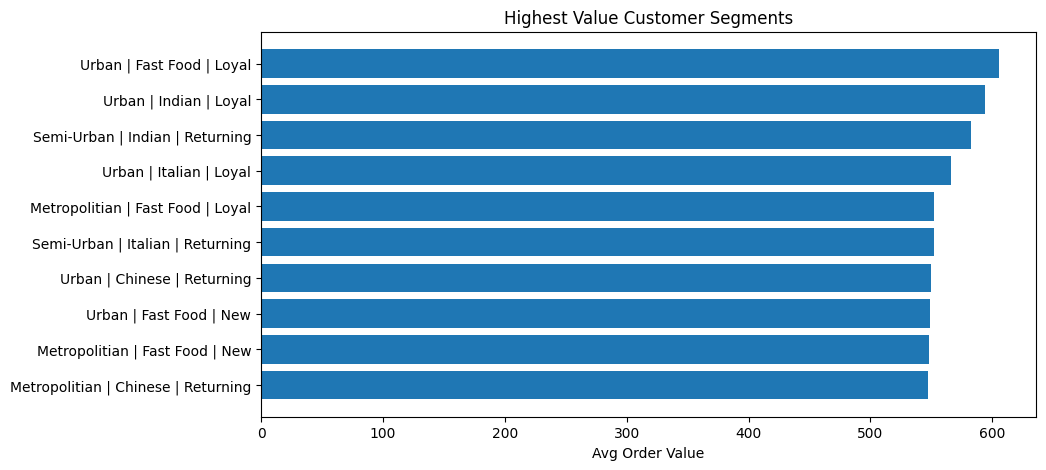

In [77]:
top_value = combo.sort_values("avg_order_value", ascending=False).head(10)

labels = (
    top_value["Region"] + " | " +
    top_value["Cuisine_Type"] + " | " +
    top_value["Customer_Type"]
)

plt.figure(figsize=(10,5))

plt.barh(labels, top_value["avg_order_value"])

plt.title("Highest Value Customer Segments")
plt.xlabel("Avg Order Value")

plt.gca().invert_yaxis()
plt.show()

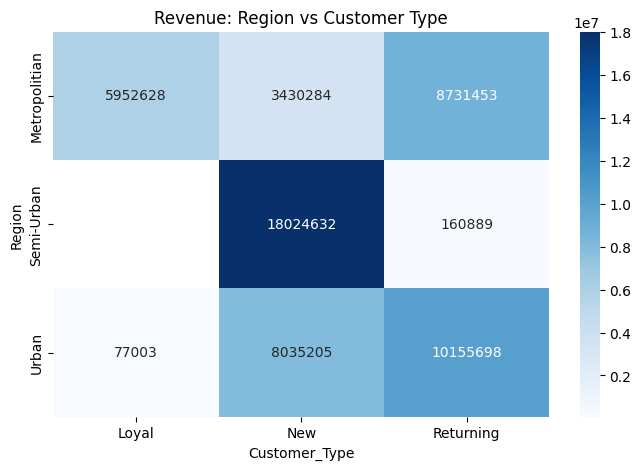

In [78]:
import seaborn as sns

pivot = combo.pivot_table(
    index="Region",
    columns="Customer_Type",
    values="total_revenue",
    aggfunc="sum"
)

plt.figure(figsize=(8,5))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="Blues")

plt.title("Revenue: Region vs Customer Type")
plt.show()

In [79]:
#Highest revenue-driving combinations

top_revenue_drivers = combo.sort_values(
    "total_revenue",
    ascending=False
).head(10)

print(top_revenue_drivers)

           Region Cuisine_Type Customer_Type  total_orders  avg_order_value  \
12     Semi-Urban      Chinese           New         10419       546.280065   
18     Semi-Urban      Italian           New          8905       544.272544   
16     Semi-Urban       Indian           New          8248       546.028613   
31          Urban      Italian     Returning          6351       546.429696   
14     Semi-Urban    Fast Food           New          5485       543.764631   
30          Urban      Italian           New          5097       543.883461   
2   Metropolitian      Chinese     Returning          4264       547.276032   
11  Metropolitian      Italian     Returning          4279       545.163823   
22          Urban      Chinese     Returning          4208       549.933935   
25          Urban    Fast Food     Returning          4128       545.325097   

    total_revenue  
12        5691692  
18        4846747  
16        4503644  
31        3470375  
14        2982549  
30        

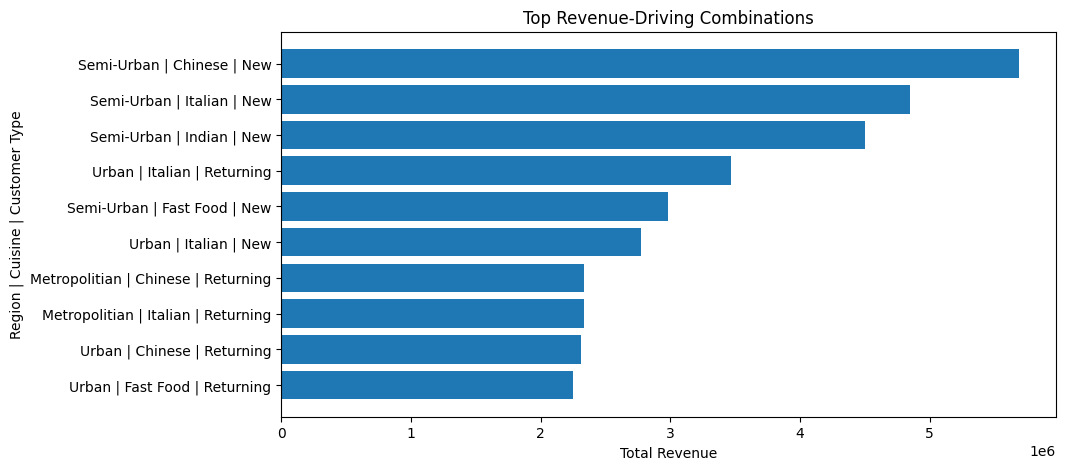

In [80]:
import matplotlib.pyplot as plt

top_revenue_drivers = combo.sort_values(
    "total_revenue",
    ascending=False
).head(10)

labels = (
    top_revenue_drivers["Region"] + " | " +
    top_revenue_drivers["Cuisine_Type"] + " | " +
    top_revenue_drivers["Customer_Type"]
)

plt.figure(figsize=(10,5))

plt.barh(labels, top_revenue_drivers["total_revenue"])

plt.title("Top Revenue-Driving Combinations")
plt.xlabel("Total Revenue")
plt.ylabel("Region | Cuisine | Customer Type")

plt.gca().invert_yaxis()

plt.show()

In [81]:
#Top by average order value (premium behavior)
premium_drivers = combo.sort_values(
    "avg_order_value",
    ascending=False
).head(10)

print(premium_drivers)

           Region Cuisine_Type Customer_Type  total_orders  avg_order_value  \
23          Urban    Fast Food         Loyal            30       605.700000   
26          Urban       Indian         Loyal            32       593.656250   
17     Semi-Urban       Indian     Returning            69       582.521739   
29          Urban      Italian         Loyal            35       566.200000   
3   Metropolitian    Fast Food         Loyal          2667       552.427822   
19     Semi-Urban      Italian     Returning            84       552.142857   
22          Urban      Chinese     Returning          4208       549.933935   
24          Urban    Fast Food           New          3241       549.282629   
4   Metropolitian    Fast Food           New          1544       548.244819   
2   Metropolitian      Chinese     Returning          4264       547.276032   

    total_revenue  
23          18171  
26          18997  
17          40194  
29          19817  
3         1473325  
19        

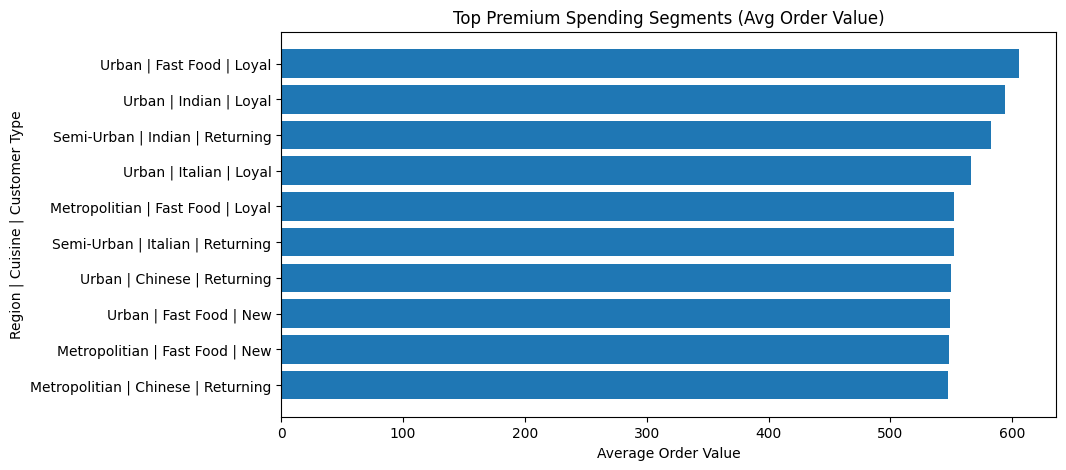

In [82]:
import matplotlib.pyplot as plt

premium_drivers = combo.sort_values(
    "avg_order_value",
    ascending=False
).head(10)

labels = (
    premium_drivers["Region"] + " | " +
    premium_drivers["Cuisine_Type"] + " | " +
    premium_drivers["Customer_Type"]
)

plt.figure(figsize=(10,5))

plt.barh(labels, premium_drivers["avg_order_value"])

plt.title("Top Premium Spending Segments (Avg Order Value)")
plt.xlabel("Average Order Value")
plt.ylabel("Region | Cuisine | Customer Type")

plt.gca().invert_yaxis()

plt.show()

In [83]:
best_per_region = combo.loc[
    combo.groupby("Region")["total_revenue"].idxmax()
]

print(best_per_region)

           Region Cuisine_Type Customer_Type  total_orders  avg_order_value  \
2   Metropolitian      Chinese     Returning          4264       547.276032   
12     Semi-Urban      Chinese           New         10419       546.280065   
31          Urban      Italian     Returning          6351       546.429696   

    total_revenue  
2         2333585  
12        5691692  
31        3470375  


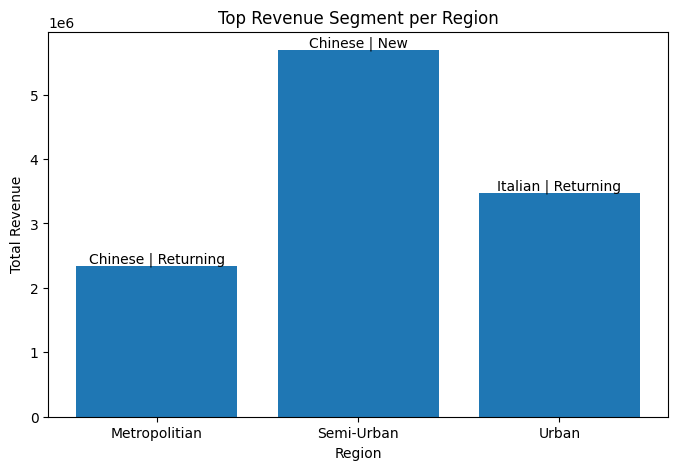

In [84]:
import matplotlib.pyplot as plt

best_per_region = combo.loc[
    combo.groupby("Region")["total_revenue"].idxmax()
]

labels = (
    best_per_region["Cuisine_Type"] + " | " +
    best_per_region["Customer_Type"]
)

plt.figure(figsize=(8,5))

plt.bar(
    best_per_region["Region"],
    best_per_region["total_revenue"]
)

plt.title("Top Revenue Segment per Region")
plt.xlabel("Region")
plt.ylabel("Total Revenue")

# annotate cuisine + customer type
for i, row in best_per_region.iterrows():
    plt.text(
        row["Region"],
        row["total_revenue"],
        labels[i],
        ha="center",
        va="bottom"
    )

plt.show()

In [85]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# GROUPING RESTAURANT METRICS
# -----------------------------

restaurant_perf = data.groupby(
    ['Restaurant_Name', 'Cuisine_Type']
).agg({
    'Avg_Rating':'mean',
    'Order_Capacity_Per_Day':'mean',
    'Avg_Preparation_Time_Minutes':'mean',
    'Final_Amount':'mean',
    'Delayed_Deliveries':'sum'
}).reset_index()


print(restaurant_perf.head())

   Restaurant_Name Cuisine_Type  Avg_Rating  Order_Capacity_Per_Day  \
0    Restaurant_10       Indian        4.64                     2.0   
1   Restaurant_100      Chinese        4.64                     1.0   
2  Restaurant_1000      Chinese        4.25                     2.0   
3  Restaurant_1001      Italian        4.64                    42.0   
4  Restaurant_1002      Italian        4.61                   110.0   

   Avg_Preparation_Time_Minutes  Final_Amount  Delayed_Deliveries  
0                          40.0    577.442029                  62  
1                          25.0    584.534884                 347  
2                          40.0    563.048558                 710  
3                          23.0    558.401408                  45  
4                          27.0    555.433628                 347  


In [86]:
#Which Cuisine Performs Best? Based on Rating and Revenue

cuisine_perf = data.groupby('Cuisine_Type').agg({
    'Avg_Rating':'mean',
    'Final_Amount':'mean',
    'Delayed_Deliveries':'sum'
}).sort_values(by='Avg_Rating', ascending=False)

print(cuisine_perf)

              Avg_Rating  Final_Amount  Delayed_Deliveries
Cuisine_Type                                              
Italian         4.606678    559.134563               38993
Fast Food       4.600883    560.676561               31777
Chinese         4.576789    560.245726               39456
Indian          4.550799    559.983466               33164


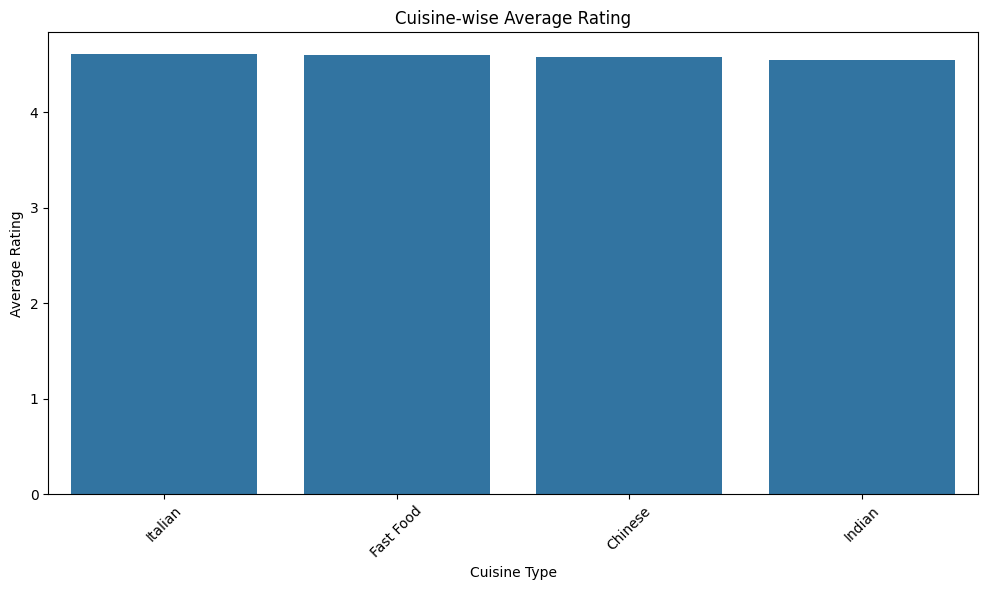

In [87]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=cuisine_perf.index,
    y=cuisine_perf['Avg_Rating']
)

plt.title("Cuisine-wise Average Rating")
plt.xticks(rotation=45)
plt.ylabel("Average Rating")
plt.xlabel("Cuisine Type")
plt.show()

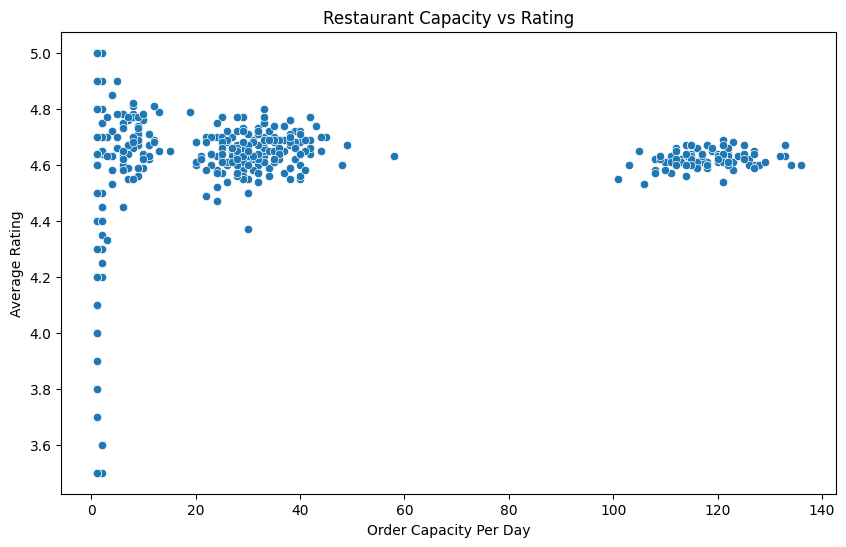

In [88]:
#Do High-Capacity Restaurants Get Lower Ratings?
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=restaurant_perf,
    x='Order_Capacity_Per_Day',
    y='Avg_Rating'
)

plt.title("Restaurant Capacity vs Rating")
plt.xlabel("Order Capacity Per Day")
plt.ylabel("Average Rating")
plt.show()

In [89]:
correlation = restaurant_perf[
    ['Order_Capacity_Per_Day', 'Avg_Rating']
].corr()

print(correlation)

                        Order_Capacity_Per_Day  Avg_Rating
Order_Capacity_Per_Day                1.000000    0.034464
Avg_Rating                            0.034464    1.000000


In [90]:
# Which Restaurants Are Operationally Efficient?
#Efficiency Logic
#Efficient restaurants should have:
#High ratings
#Low delays
#Lower preparation time

restaurant_perf['Operational_Efficiency'] = (
    restaurant_perf['Avg_Rating'] * 10
    - restaurant_perf['Avg_Preparation_Time_Minutes']
    - restaurant_perf['Delayed_Deliveries']
)

top_efficient = restaurant_perf.sort_values(
    by='Operational_Efficiency',
    ascending=False
)

print(top_efficient.head(10))

     Restaurant_Name Cuisine_Type  Avg_Rating  Order_Capacity_Per_Day  \
543   Restaurant_986       Indian        4.66                    39.0   
70   Restaurant_1143      Italian        4.59                     7.0   
24   Restaurant_1040      Italian        4.60                     6.0   
270    Restaurant_44      Italian        4.64                     1.0   
3    Restaurant_1001      Italian        4.64                    42.0   
474   Restaurant_849      Chinese        4.78                    10.0   
238   Restaurant_376    Fast Food        4.63                    33.0   
416   Restaurant_724      Chinese        4.77                    42.0   
97   Restaurant_1209      Italian        4.66                     8.0   
370   Restaurant_628       Indian        4.64                    40.0   

     Avg_Preparation_Time_Minutes  Final_Amount  Delayed_Deliveries  \
543                          23.0    567.261194                  40   
70                           20.0    559.342657       

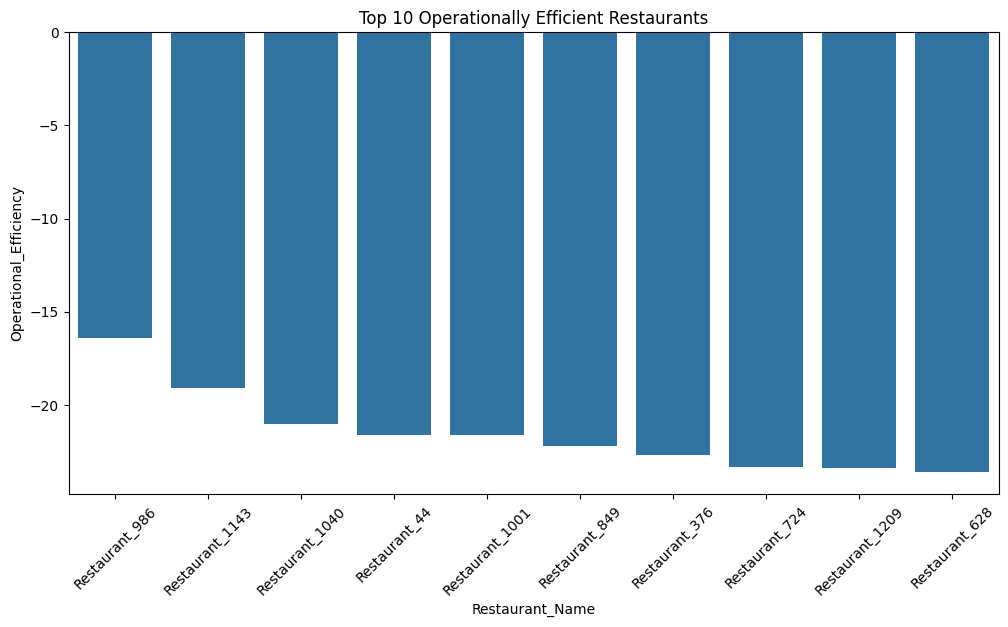

In [91]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_efficient.head(10),
    x='Restaurant_Name',
    y='Operational_Efficiency'
)

plt.title("Top 10 Operationally Efficient Restaurants")
plt.xticks(rotation=45)
plt.show()

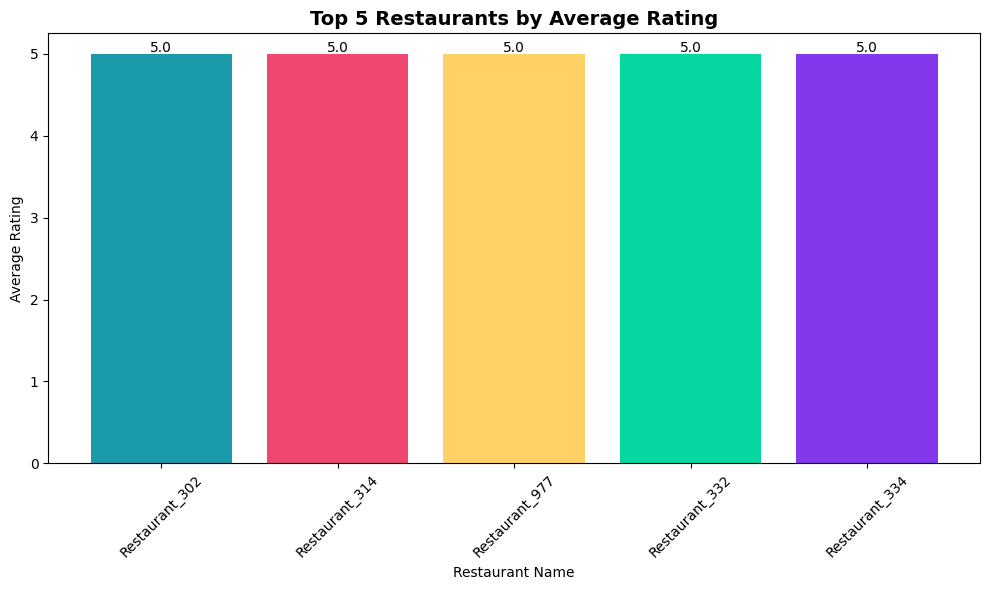

In [139]:
import matplotlib.pyplot as plt

# Top 5 restaurants based on average rating
top_rated = restaurant_perf.sort_values(
    by='Avg_Rating',
    ascending=False
).head(5)

# New premium color palette
colors = ['#1B9AAA', '#EF476F', '#FFD166', '#06D6A0', '#8338EC']

# Plot
plt.figure(figsize=(10,6))

bars = plt.bar(
    top_rated['Restaurant_Name'],
    top_rated['Avg_Rating'],
    color=colors
)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.02,
        round(height, 2),
        ha='center'
    )

# Titles and labels
plt.title("Top 5 Restaurants by Average Rating", fontsize=14, fontweight='bold')
plt.xlabel("Restaurant Name")
plt.ylabel("Average Rating")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

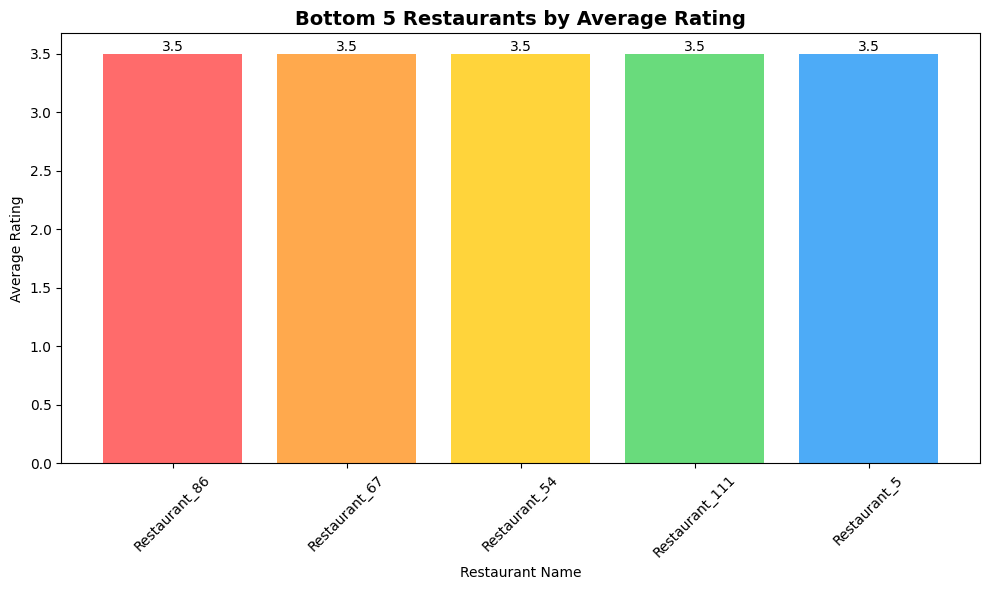

In [137]:
import matplotlib.pyplot as plt

# Bottom 5 restaurants based on average rating
bottom_rated = restaurant_perf.sort_values(
    by='Avg_Rating',
    ascending=True
).head(5)

# Better color palette
colors = ['#FF6B6B', '#FFA94D', '#FFD43B', '#69DB7C', '#4DABF7']

# Plot
plt.figure(figsize=(10,6))

bars = plt.bar(
    bottom_rated['Restaurant_Name'],
    bottom_rated['Avg_Rating'],
    color=colors
)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.02,
        round(height, 2),
        ha='center'
    )

# Titles and labels
plt.title("Bottom 5 Restaurants by Average Rating", fontsize=14, fontweight='bold')
plt.xlabel("Restaurant Name")
plt.ylabel("Average Rating")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [94]:
top_rated = restaurant_perf.sort_values(
    by='Avg_Rating',
    ascending=False
)

print(top_rated.head(10))

    Restaurant_Name Cuisine_Type  Avg_Rating  Order_Capacity_Per_Day  \
194  Restaurant_302       Indian         5.0                     1.0   
205  Restaurant_314    Fast Food         5.0                     1.0   
537  Restaurant_977      Chinese         5.0                     1.0   
216  Restaurant_332    Fast Food         5.0                     1.0   
218  Restaurant_334      Chinese         5.0                     1.0   
183   Restaurant_29      Chinese         5.0                     1.0   
176  Restaurant_274      Italian         5.0                     2.0   
186  Restaurant_292    Fast Food         5.0                     1.0   
164  Restaurant_249       Indian         5.0                     1.0   
356   Restaurant_60    Fast Food         5.0                     1.0   

     Avg_Preparation_Time_Minutes  Final_Amount  Delayed_Deliveries  \
194                          20.0    556.830000                 306   
205                          26.0    557.369231                 3

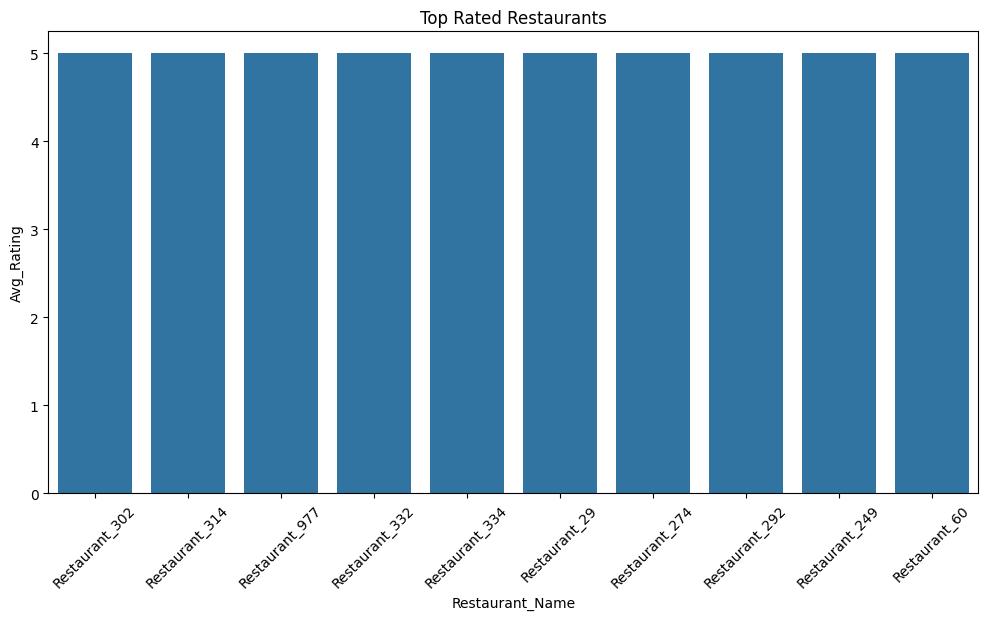

In [95]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_rated.head(10),
    x='Restaurant_Name',
    y='Avg_Rating'
)

plt.title("Top Rated Restaurants")
plt.xticks(rotation=45)
plt.show()

In [96]:
high_capacity = restaurant_perf.sort_values(
    by='Order_Capacity_Per_Day',
    ascending=False
)

print(high_capacity.head(10))

     Restaurant_Name Cuisine_Type  Avg_Rating  Order_Capacity_Per_Day  \
505   Restaurant_910       Indian        4.60                   136.0   
465   Restaurant_826       Indian        4.60                   134.0   
45   Restaurant_1084      Chinese        4.67                   133.0   
48   Restaurant_1090      Italian        4.63                   133.0   
322   Restaurant_549    Fast Food        4.63                   132.0   
367   Restaurant_621    Fast Food        4.61                   129.0   
295   Restaurant_493    Fast Food        4.60                   128.0   
417   Restaurant_727      Italian        4.64                   127.0   
60   Restaurant_1119      Italian        4.65                   127.0   
546   Restaurant_992      Italian        4.59                   127.0   

     Avg_Preparation_Time_Minutes  Final_Amount  Delayed_Deliveries  \
505                          27.0    560.984615                 370   
465                          29.0    563.510638       

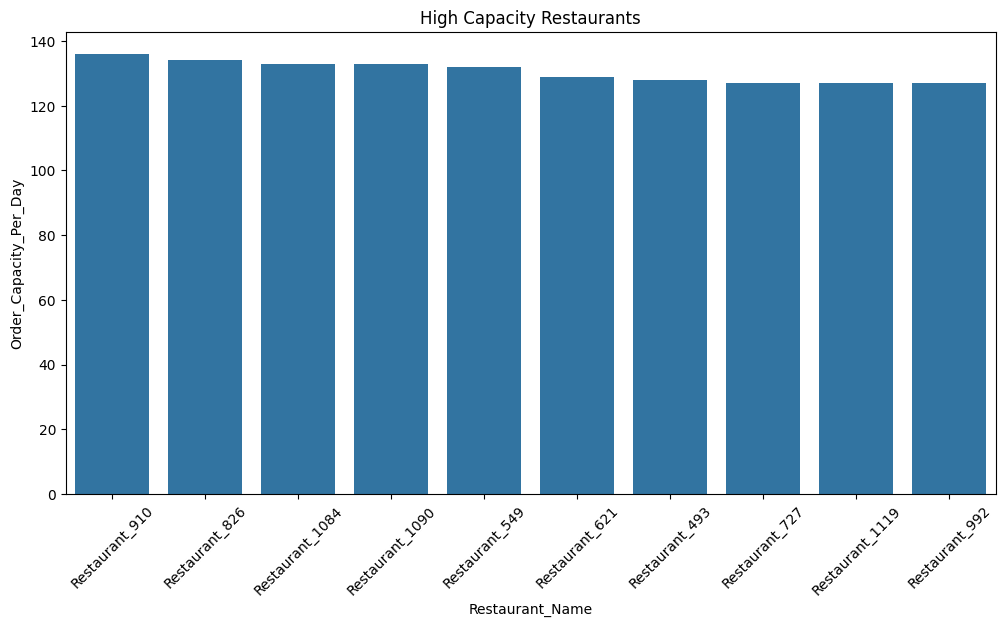

In [97]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=high_capacity.head(10),
    x='Restaurant_Name',
    y='Order_Capacity_Per_Day'
)

plt.title("High Capacity Restaurants")
plt.xticks(rotation=45)
plt.show()

In [98]:
most_delays = restaurant_perf.sort_values(
    by='Delayed_Deliveries',
    ascending=False
)

print(most_delays.head(10))

     Restaurant_Name Cuisine_Type  Avg_Rating  Order_Capacity_Per_Day  \
102   Restaurant_123      Italian        4.64                     1.0   
512   Restaurant_921      Italian        3.70                     1.0   
537   Restaurant_977      Chinese        5.00                     1.0   
246   Restaurant_394    Fast Food        4.60                     1.0   
468   Restaurant_842       Indian        4.70                     1.0   
501   Restaurant_901      Chinese        4.50                     1.0   
534   Restaurant_967      Chinese        4.45                     2.0   
54   Restaurant_1108      Chinese        4.70                     2.0   
46   Restaurant_1088    Fast Food        4.40                     1.0   
259   Restaurant_427       Indian        4.00                     1.0   

     Avg_Preparation_Time_Minutes  Final_Amount  Delayed_Deliveries  \
102                          40.0    560.131824                 794   
512                          40.0    548.836653       

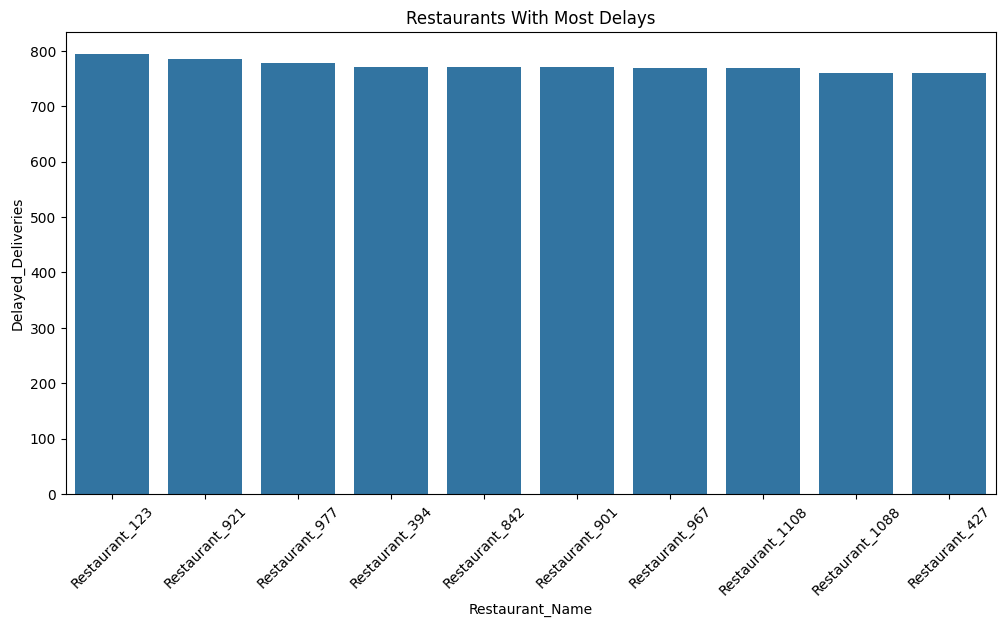

In [99]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=most_delays.head(10),
    x='Restaurant_Name',
    y='Delayed_Deliveries'
)

plt.title("Restaurants With Most Delays")
plt.xticks(rotation=45)
plt.show()

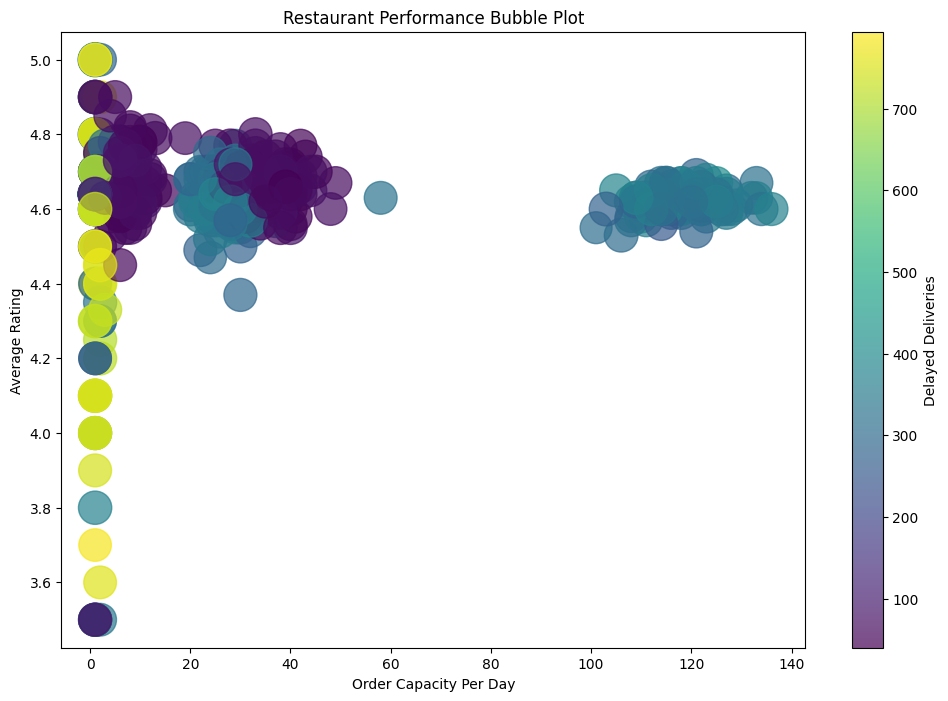

In [100]:
plt.figure(figsize=(12,8))

scatter = plt.scatter(
    restaurant_perf['Order_Capacity_Per_Day'],
    restaurant_perf['Avg_Rating'],
    s=restaurant_perf['Final_Amount'],
    c=restaurant_perf['Delayed_Deliveries'],
    alpha=0.7
)

plt.xlabel("Order Capacity Per Day")
plt.ylabel("Average Rating")
plt.title("Restaurant Performance Bubble Plot")

plt.colorbar(label='Delayed Deliveries')

plt.show()

In [101]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# CONVERT DATE COLUMN
# -----------------------------

data['Order_Date'] = pd.to_datetime(data['Order_Date'])

# Extract month name
data['Month'] = data['Order_Date'].dt.month_name()

# Optional: Extract quarter/season
data['Quarter'] = data['Order_Date'].dt.quarter

# -----------------------------
# CUSTOMER TYPE VS MONTH
# -----------------------------

customer_month = data.groupby(
    ['Month', 'Customer_Type']
).size().reset_index(name='Total_Orders')

print(customer_month.head())

    Month Customer_Type  Total_Orders
0   April         Loyal           839
1   April           New          4268
2   April     Returning          2729
3  August         Loyal           988
4  August           New          4500


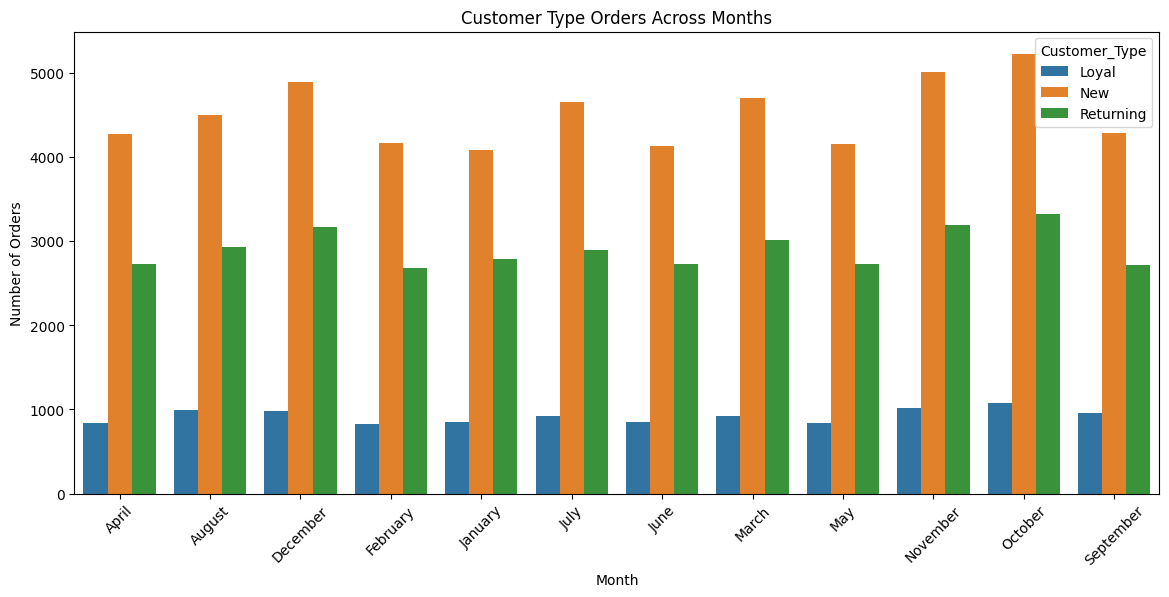

In [102]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=customer_month,
    x='Month',
    y='Total_Orders',
    hue='Customer_Type'
)

plt.title("Customer Type Orders Across Months")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.show()

In [103]:
peak_months = customer_month.loc[
    customer_month.groupby('Customer_Type')['Total_Orders'].idxmax()
]

print(peak_months)

      Month Customer_Type  Total_Orders
30  October         Loyal          1070
31  October           New          5228
32  October     Returning          3316


In [104]:
new_customers = data[data['Customer_Type'] == 'New']

new_month = new_customers.groupby('Month').size().reset_index(name='Orders')

print(new_month.sort_values(by='Orders', ascending=False))

        Month  Orders
10    October    5228
9    November    5007
2    December    4893
7       March    4698
5        July    4650
1      August    4500
11  September    4285
0       April    4268
3    February    4171
8         May    4148
6        June    4134
4     January    4085


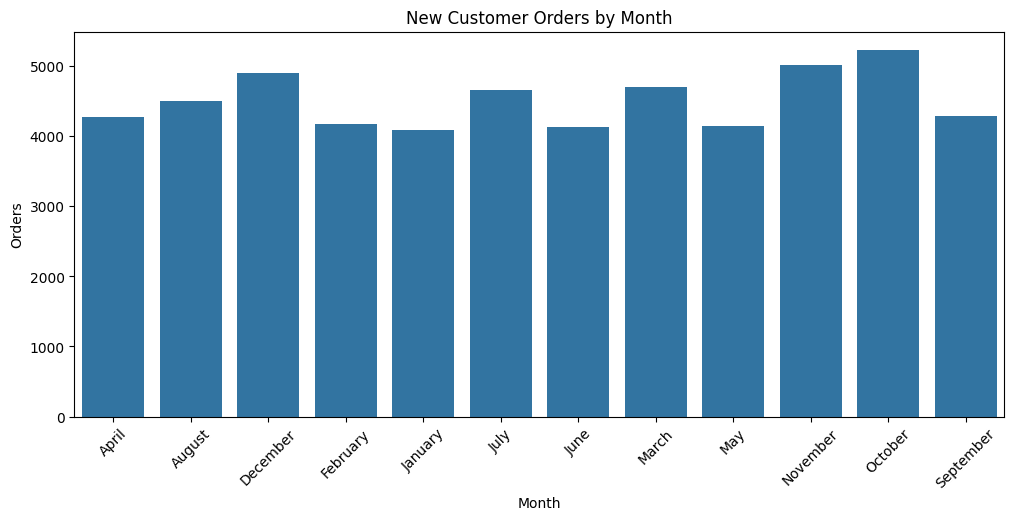

In [105]:
plt.figure(figsize=(12,5))

sns.barplot(
    data=new_month,
    x='Month',
    y='Orders'
)

plt.title("New Customer Orders by Month")
plt.xticks(rotation=45)

plt.show()

In [106]:
# Convert to datetime
data['Order_Date'] = pd.to_datetime(data['Order_Date'])

# Extract year
data['Year'] = data['Order_Date'].dt.year

# Extract month name
data['Month'] = data['Order_Date'].dt.month_name()

# Extract Year-Month together
data['Year_Month'] = data['Order_Date'].dt.strftime('%Y-%m')

In [107]:
customer_trend = data.groupby(
    ['Year_Month', 'Customer_Type']
).size().reset_index(name='Orders')

print(customer_trend.head())

  Year_Month Customer_Type  Orders
0    2023-01         Loyal     269
1    2023-01           New    1370
2    2023-01     Returning     921
3    2023-02         Loyal     271
4    2023-02           New    1399


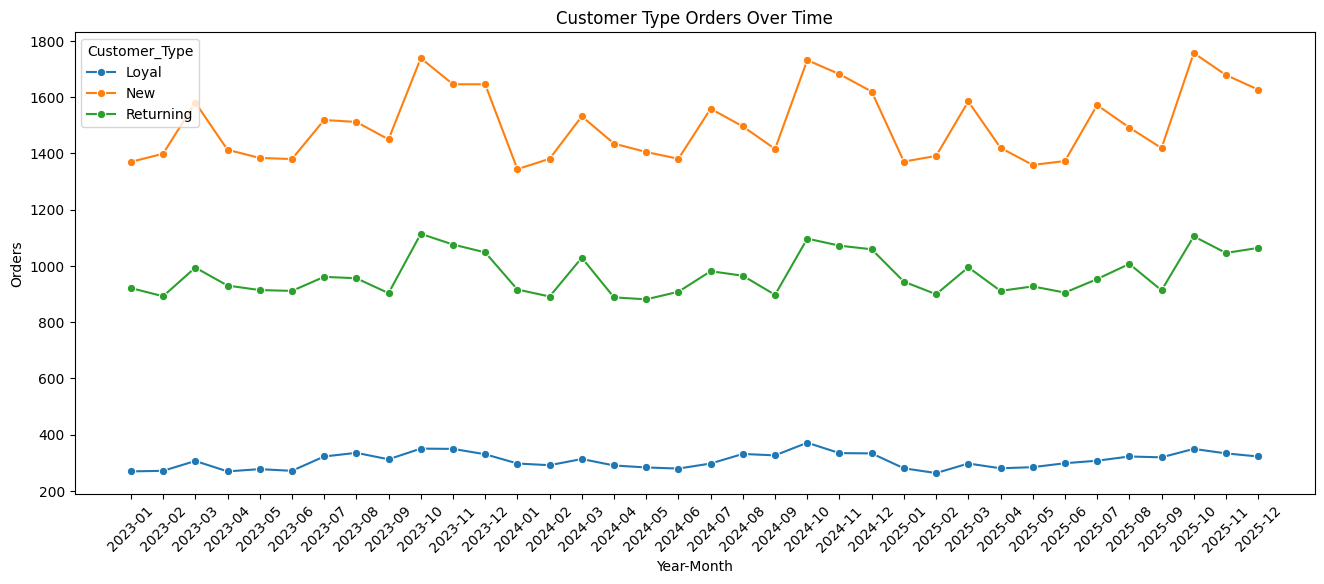

In [108]:
plt.figure(figsize=(16,6))

sns.lineplot(
    data=customer_trend,
    x='Year_Month',
    y='Orders',
    hue='Customer_Type',
    marker='o'
)

plt.title("Customer Type Orders Over Time")
plt.xlabel("Year-Month")
plt.ylabel("Orders")

plt.xticks(rotation=45)

plt.show()

In [109]:
data.corr(numeric_only=True)["Order_Rating"].sort_values(ascending=False)

Order_Rating                    1.000000
Discount_Applied                0.005543
Delay_Flag                      0.004511
Avg_Preparation_Time_Minutes    0.002703
Average_Spend                   0.000230
Successful_Deliveries          -0.000459
Total_Orders                   -0.000550
Avg_Delivery_Speed_KMPH        -0.000732
Delivery_Fee                   -0.001096
Year                           -0.001428
Order_Capacity_Per_Day         -0.002076
Quarter                        -0.002136
Delivery_Time_Minutes          -0.002191
Delivery_Efficiency_Score      -0.002310
Delayed_Deliveries             -0.002869
Order_Value                    -0.003235
Avg_Rating                     -0.003693
Avg_Customer_Rating            -0.004268
Final_Amount                   -0.004491
Name: Order_Rating, dtype: float64

In [110]:
data["Order_Rating"].describe().round(2)

count    100000.00
mean          4.02
std           0.93
min           1.00
25%           4.00
50%           4.00
75%           5.00
max           5.00
Name: Order_Rating, dtype: float64

<Axes: >

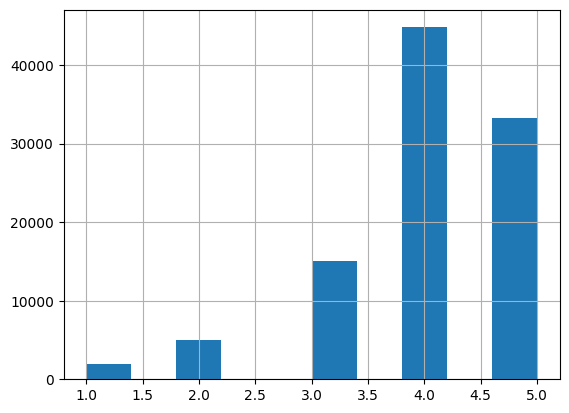

In [111]:
data["Order_Rating"].hist()

In [112]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# VEHICLE TYPE ANALYSIS
# -----------------------------

vehicle_analysis = data.groupby('Vehicle_Type').agg({
    'Order_ID':'count',
    'Avg_Customer_Rating':'mean',
    'Delivery_Time_Minutes':'mean',
    'Delayed_Deliveries':'sum',
    'Successful_Deliveries':'sum',
    'Delivery_Efficiency_Score':'mean',
    'Avg_Delivery_Speed_KMPH':'mean',
    'Final_Amount':'mean'
}).reset_index()

# Rename columns
vehicle_analysis.rename(columns={
    'Order_ID':'Total_Orders'
}, inplace=True)

print(vehicle_analysis)

  Vehicle_Type  Total_Orders  Avg_Customer_Rating  Delivery_Time_Minutes  \
0      Bicycle          4210             4.660168              35.406176   
1         Bike         46794             4.582626              35.514083   
2          Car         18996             4.633362              35.504001   
3      Scooter         30000             4.606481              35.507200   

   Delayed_Deliveries  Successful_Deliveries  Delivery_Efficiency_Score  \
0                6444                  43151                   0.678658   
1               66429                 490490                   0.697542   
2               25523                 134859                   0.613425   
3               44994                 336638                   0.708247   

   Avg_Delivery_Speed_KMPH  Final_Amount  
0                20.762021    556.803800  
1                20.230152    559.835128  
2                19.783105    560.341967  
3                21.257309    560.330233  


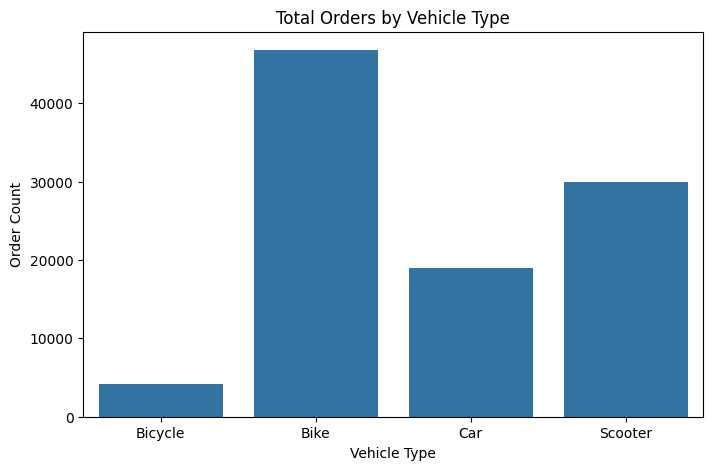

In [113]:
#Order Count by Vehicle Type
plt.figure(figsize=(8,5))

sns.barplot(
    data=vehicle_analysis,
    x='Vehicle_Type',
    y='Total_Orders'
)

plt.title("Total Orders by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Order Count")

plt.show()

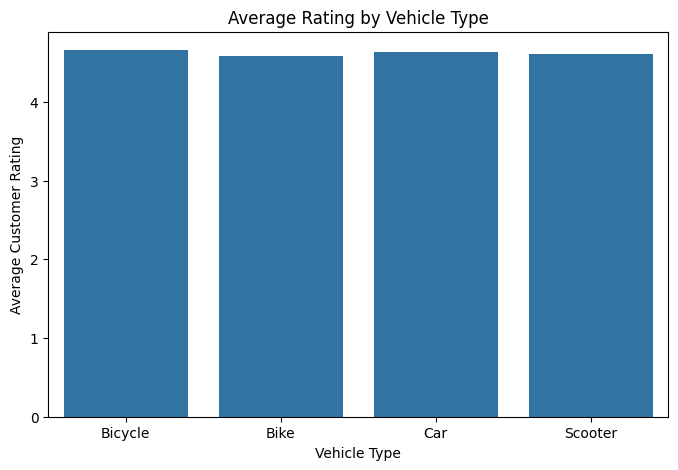

In [114]:
#Average Customer Rating by Vehicle Type
plt.figure(figsize=(8,5))

sns.barplot(
    data=vehicle_analysis,
    x='Vehicle_Type',
    y='Avg_Customer_Rating'
)

plt.title("Average Rating by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Average Customer Rating")

plt.show()

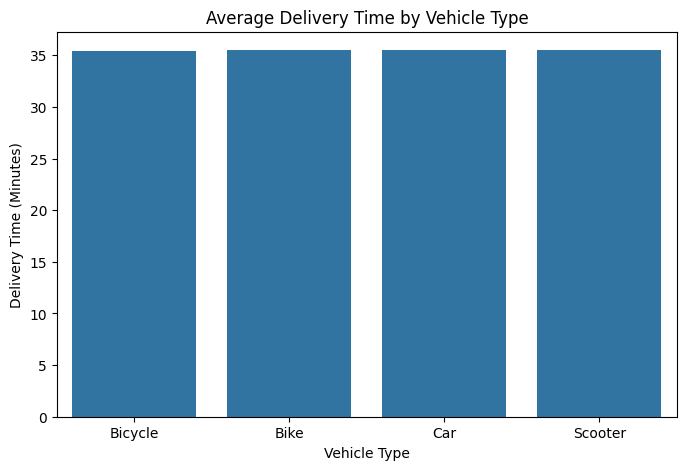

In [115]:
#Delivery Time by Vehicle Type
plt.figure(figsize=(8,5))

sns.barplot(
    data=vehicle_analysis,
    x='Vehicle_Type',
    y='Delivery_Time_Minutes'
)

plt.title("Average Delivery Time by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Delivery Time (Minutes)")

plt.show()

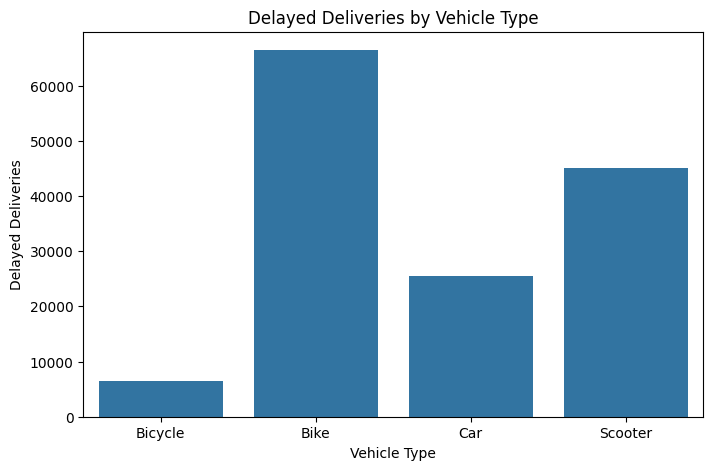

In [116]:
#Delayed Deliveries by Vehicle Type
plt.figure(figsize=(8,5))

sns.barplot(
    data=vehicle_analysis,
    x='Vehicle_Type',
    y='Delayed_Deliveries'
)

plt.title("Delayed Deliveries by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Delayed Deliveries")

plt.show()

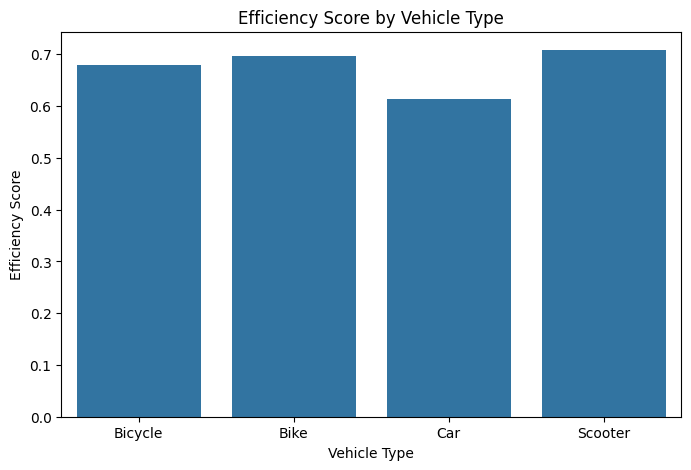

In [117]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=vehicle_analysis,
    x='Vehicle_Type',
    y='Delivery_Efficiency_Score'
)

plt.title("Efficiency Score by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Efficiency Score")

plt.show()

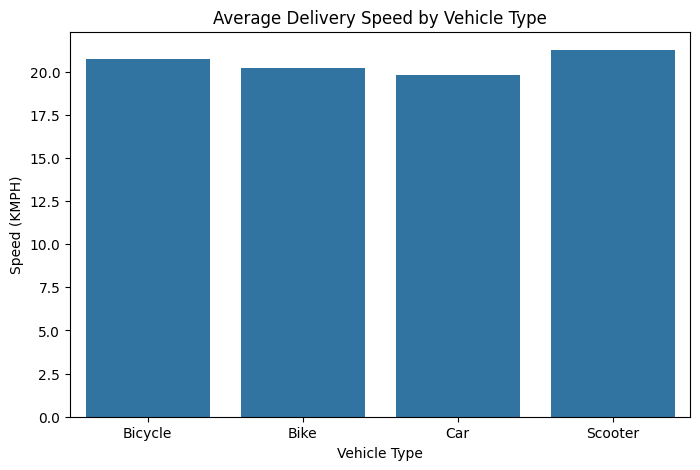

In [118]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=vehicle_analysis,
    x='Vehicle_Type',
    y='Avg_Delivery_Speed_KMPH'
)

plt.title("Average Delivery Speed by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Speed (KMPH)")

plt.show()

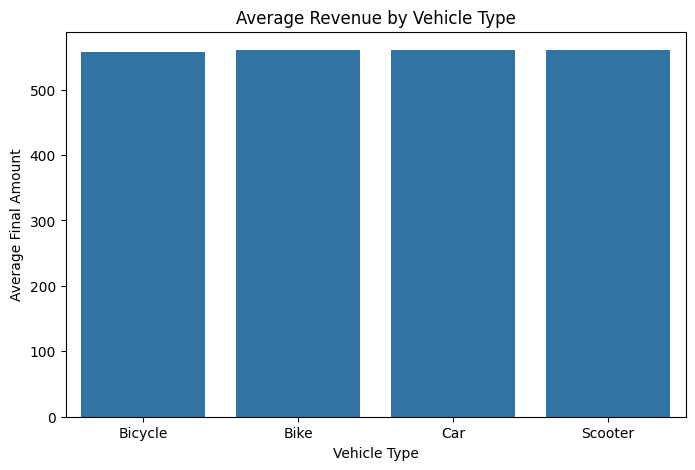

In [119]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=vehicle_analysis,
    x='Vehicle_Type',
    y='Final_Amount'
)

plt.title("Average Revenue by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Average Final Amount")

plt.show()

In [120]:
car_partners = data[data['Vehicle_Type'] == 'Car']

car_analysis = car_partners.groupby('Partner_Name').agg({
    'Order_ID':'count',
    'Avg_Customer_Rating':'mean',
    'Delivery_Time_Minutes':'mean',
    'Delayed_Deliveries':'sum',
    'Successful_Deliveries':'sum',
    'Delivery_Efficiency_Score':'mean'
}).reset_index()

car_analysis.rename(columns={
    'Order_ID':'Total_Orders'
}, inplace=True)

print(car_analysis.sort_values(by='Total_Orders', ascending=False))

     Partner_Name  Total_Orders  Avg_Customer_Rating  Delivery_Time_Minutes  \
15    Arjun Singh          1135             4.286511              35.644934   
67    Suresh Iyer           903             4.807752              35.416390   
18    Kiran Gupta           765             4.887833              35.352941   
71  Suresh Sharma           648             4.637847              35.214506   
8       Arjun Das           645             4.612663              35.443411   
..            ...           ...                  ...                    ...   
37  Rajesh Chopra            58             4.520000              35.948276   
73  Vikram Chopra            58             4.675000              35.965517   
19     Kiran Iyer            55             4.700000              35.290909   
4     Anita Patel            53             4.736364              35.566038   
27    Meena Kumar            48             4.833333              35.020833   

    Delayed_Deliveries  Successful_Deliveries  Deli

In [121]:
top_car_rating = car_analysis.sort_values(
    by='Avg_Customer_Rating',
    ascending=False
)

print(top_car_rating.head(10))

    Partner_Name  Total_Orders  Avg_Customer_Rating  Delivery_Time_Minutes  \
77   Vikram Nair            75             5.133333              35.120000   
43  Rajesh Patel            63             5.000000              35.222222   
28    Meena Nair           584             4.990925              35.467466   
9    Arjun Gupta           538             4.970446              35.631970   
29   Meena Patel           627             4.899910              35.692185   
18   Kiran Gupta           765             4.887833              35.352941   
27   Meena Kumar            48             4.833333              35.020833   
76  Vikram Kumar           193             4.819344              35.419689   
67   Suresh Iyer           903             4.807752              35.416390   
45  Rajesh Singh            80             4.783333              34.975000   

    Delayed_Deliveries  Successful_Deliveries  Delivery_Efficiency_Score  
77                   0                    225                   0.

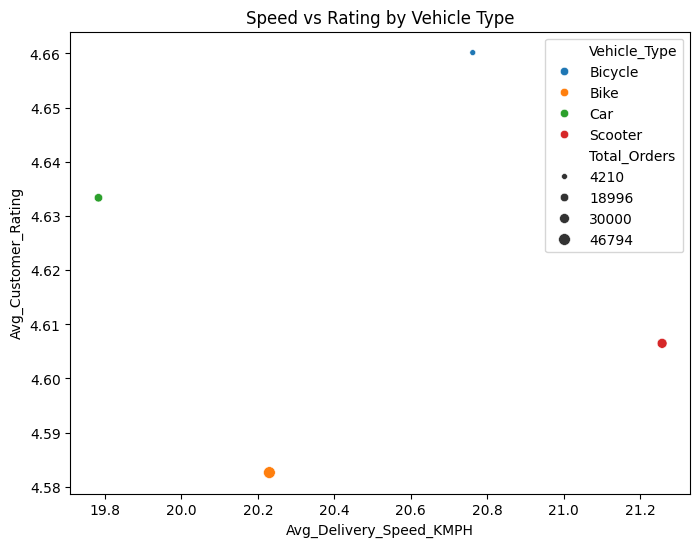

In [122]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=vehicle_analysis,
    x='Avg_Delivery_Speed_KMPH',
    y='Avg_Customer_Rating',
    size='Total_Orders',
    hue='Vehicle_Type'
)

plt.title("Speed vs Rating by Vehicle Type")

plt.show()

In [123]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# VEHICLE TYPE COUNT BY REGION
# -----------------------------

vehicle_region = data.groupby(
    ['Region', 'Vehicle_Type']
).size().reset_index(name='Vehicle_Count')

print(vehicle_region)

           Region Vehicle_Type  Vehicle_Count
0   Metropolitian      Bicycle           1252
1   Metropolitian         Bike          16162
2   Metropolitian          Car           5010
3   Metropolitian      Scooter          10806
4      Semi-Urban      Bicycle           1411
5      Semi-Urban         Bike          13989
6      Semi-Urban          Car           9242
7      Semi-Urban      Scooter           8707
8           Urban      Bicycle           1547
9           Urban         Bike          16643
10          Urban          Car           4744
11          Urban      Scooter          10487


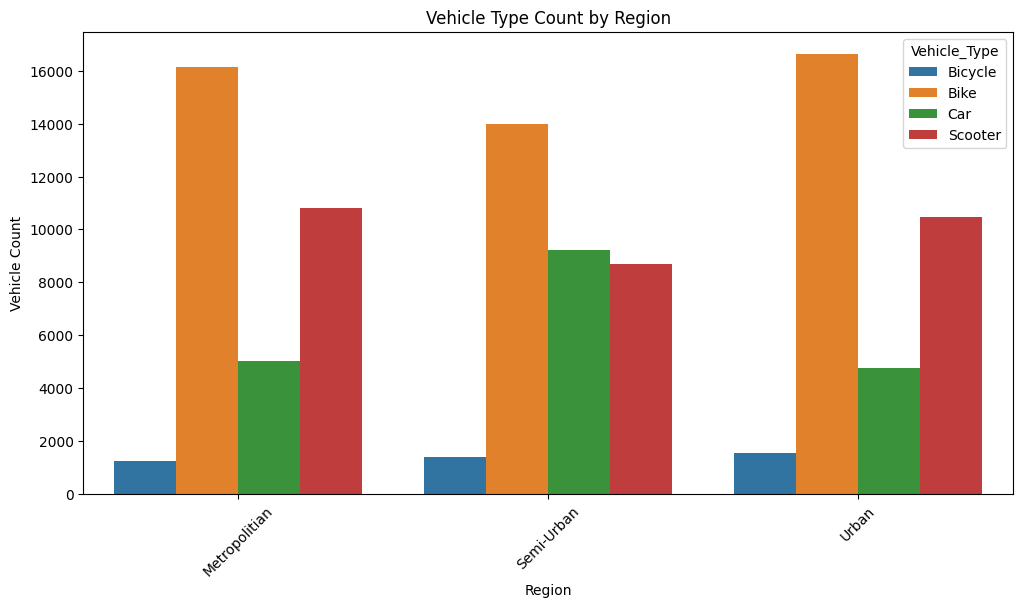

In [124]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=vehicle_region,
    x='Region',
    y='Vehicle_Count',
    hue='Vehicle_Type'
)

plt.title("Vehicle Type Count by Region")
plt.xlabel("Region")
plt.ylabel("Vehicle Count")

plt.xticks(rotation=45)

plt.show()

In [125]:
delay_analysis = data.groupby(
    ['Region', 'Vehicle_Type']
)['Delayed_Deliveries'].sum().reset_index()

print(delay_analysis)

           Region Vehicle_Type  Delayed_Deliveries
0   Metropolitian      Bicycle                4180
1   Metropolitian         Bike               44558
2   Metropolitian          Car               13829
3   Metropolitian      Scooter               31546
4      Semi-Urban      Bicycle                1411
5      Semi-Urban         Bike               14933
6      Semi-Urban          Car                9738
7      Semi-Urban      Scooter                9182
8           Urban      Bicycle                 853
9           Urban         Bike                6938
10          Urban          Car                1956
11          Urban      Scooter                4266


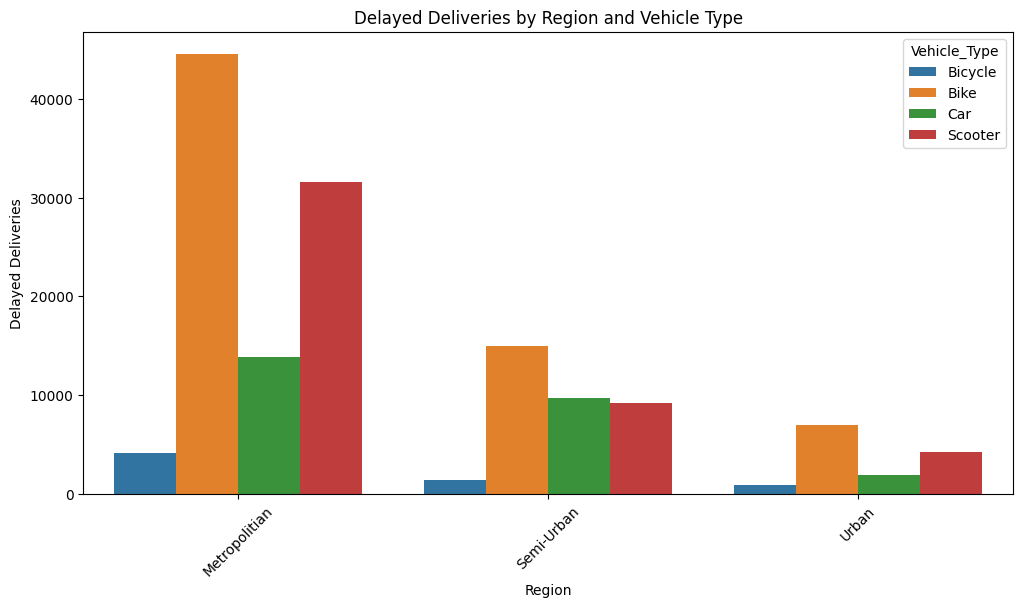

In [126]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=delay_analysis,
    x='Region',
    y='Delayed_Deliveries',
    hue='Vehicle_Type'
)

plt.title("Delayed Deliveries by Region and Vehicle Type")
plt.xlabel("Region")
plt.ylabel("Delayed Deliveries")

plt.xticks(rotation=45)

plt.show()

In [127]:
max_delay = delay_analysis.loc[
    delay_analysis.groupby('Region')['Delayed_Deliveries'].idxmax()
]

print(max_delay)

          Region Vehicle_Type  Delayed_Deliveries
1  Metropolitian         Bike               44558
5     Semi-Urban         Bike               14933
9          Urban         Bike                6938


  Vehicle_Type  Final_Amount
0      Bicycle    556.803800
1         Bike    559.835128
2          Car    560.341967
3      Scooter    560.330233


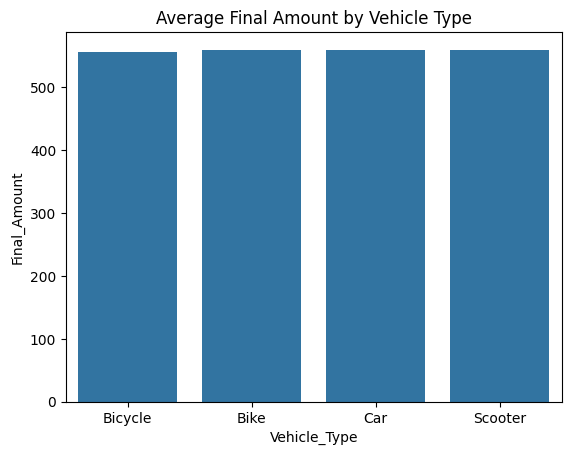

In [128]:
vehicle_order_value = data.groupby('Vehicle_Type')['Final_Amount'].mean().reset_index()

print(vehicle_order_value)

sns.barplot(
    data=vehicle_order_value,
    x='Vehicle_Type',
    y='Final_Amount'
)

plt.title("Average Final Amount by Vehicle Type")
plt.show()

  Festival_Flag Vehicle_Type  Orders
0      FESTIVAL      Bicycle    2240
1      FESTIVAL         Bike   25026
2      FESTIVAL          Car   10064
3      FESTIVAL      Scooter   16069
4  NON-FESTIVAL      Bicycle    1970
5  NON-FESTIVAL         Bike   21768
6  NON-FESTIVAL          Car    8932
7  NON-FESTIVAL      Scooter   13931


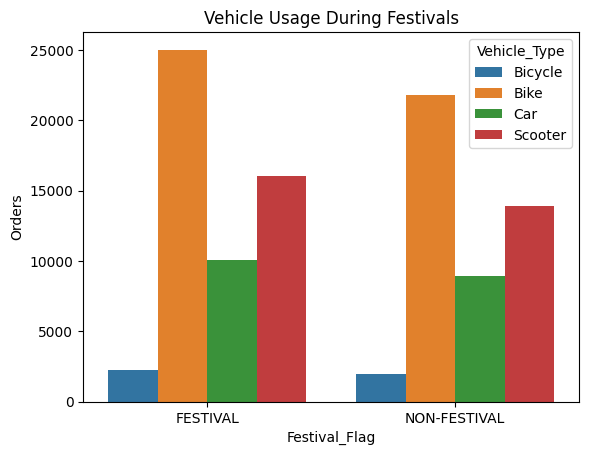

In [129]:
festival_vehicle = data.groupby(
    ['Festival_Flag', 'Vehicle_Type']
).size().reset_index(name='Orders')

print(festival_vehicle)

sns.barplot(
    data=festival_vehicle,
    x='Festival_Flag',
    y='Orders',
    hue='Vehicle_Type'
)

plt.title("Vehicle Usage During Festivals")
plt.show()

In [130]:
car_region = data[data['Vehicle_Type'] == 'Car']

In [131]:
car_cuisine = car_region.groupby('Cuisine_Type').size().reset_index(name='Orders')

print(car_cuisine.sort_values(by='Orders', ascending=False))

  Cuisine_Type  Orders
3      Italian    5422
0      Chinese    5289
2       Indian    4536
1    Fast Food    3749


In [132]:
car_customer = car_region.groupby('Customer_Type').size().reset_index(name='Orders')

print(car_customer)

  Customer_Type  Orders
0         Loyal    1684
1           New   12255
2     Returning    5057


In [133]:
#Restaurant Capacity vs Car Usage
car_capacity = car_region.groupby('Restaurant_Name')[
    'Order_Capacity_Per_Day'
].mean().reset_index()

print(car_capacity.sort_values(by='Order_Capacity_Per_Day', ascending=False))

     Restaurant_Name  Order_Capacity_Per_Day
505   Restaurant_910                   136.0
465   Restaurant_826                   134.0
45   Restaurant_1084                   133.0
48   Restaurant_1090                   133.0
322   Restaurant_549                   132.0
..               ...                     ...
501   Restaurant_901                     1.0
165    Restaurant_25                     1.0
164   Restaurant_249                     1.0
490    Restaurant_88                     1.0
31    Restaurant_106                     1.0

[550 rows x 2 columns]


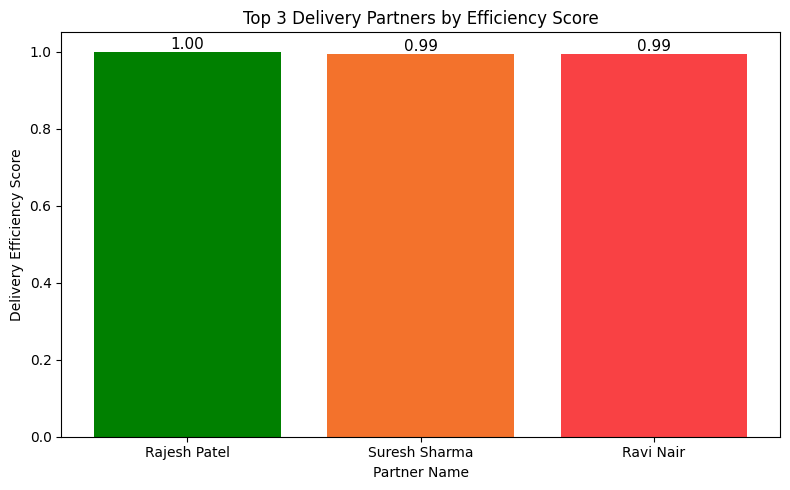

In [144]:
import matplotlib.pyplot as plt

# Group by partner
partner_efficiency = data.groupby(
    ['Delivery_Partner_ID', 'Partner_Name']
)['Delivery_Efficiency_Score'].mean().reset_index()

# Top 3 partners
top_3 = partner_efficiency.sort_values(
    by='Delivery_Efficiency_Score',
    ascending=False
).head(3)

# Plot
plt.figure(figsize=(8,5))

bars = plt.bar(
    top_3['Partner_Name'],
    top_3['Delivery_Efficiency_Score'],
    color=['green', '#F3722C', '#F94144']
)

# Data labels
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.2f}',
        ha='center',
        va='bottom',
        fontsize=11
    )

# Titles and labels
plt.title("Top 3 Delivery Partners by Efficiency Score")
plt.xlabel("Partner Name")
plt.ylabel("Delivery Efficiency Score")

plt.tight_layout()
plt.show()

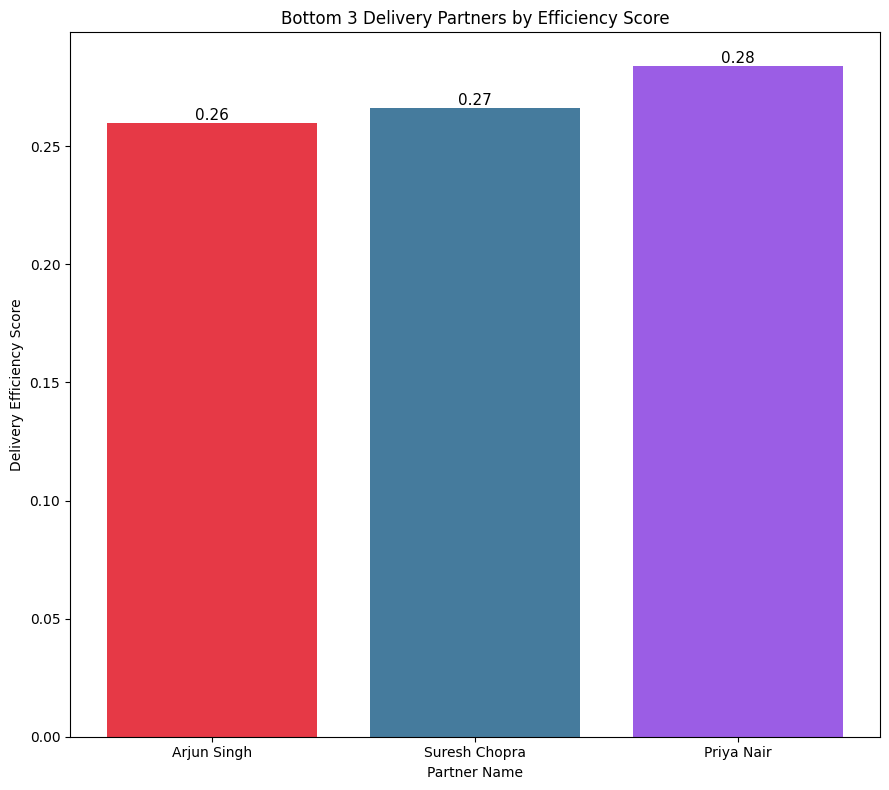

In [141]:
# ---------------- BOTTOM 3 PARTNERS ---------------- #

bottom_3 = partner_efficiency.sort_values(
    by='Delivery_Efficiency_Score',
    ascending=True
).head(3)

plt.figure(figsize=(9,8))

bars = plt.bar(
    bottom_3['Partner_Name'],
    bottom_3['Delivery_Efficiency_Score'],
    color=['#E63946', '#457B9D', '#9B5DE5']
)

# Data labels
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,   # x position
        height,                            # y position
        f'{height:.2f}',                   # label text
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.title("Bottom 3 Delivery Partners by Efficiency Score")
plt.xlabel("Partner Name")
plt.ylabel("Delivery Efficiency Score")

plt.tight_layout()
plt.show()

In [136]:
data['Delivery_Efficiency_Score'].value_counts()

Delivery_Efficiency_Score
0.812    3065
0.460    1437
0.821    1048
0.811    1028
0.374     987
         ... 
0.930      54
0.970      53
0.967      53
0.629      50
0.903      47
Name: count, Length: 312, dtype: int64